first, let's import the packages needed

In [1]:
#Imports

#Dependencias
import pandas as pd
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix

In [2]:
#!pip install seaborn --upgrade

In [3]:
#sns.__version__

Importing the Dataset

In [4]:
df = pd.read_csv("C:\\Users\\dilan\\Downloads\\train.csv")

OBSERVAR O PANORAMA GERAL DO DATASET

objetivos: 
* variáveis
* tipo de variáveis
* descrição das variáveis
* valores nulos
* valores das variáveis

In [5]:
df.head()

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  object 
 3   room_type               74111 non-null  object 
 4   amenities               74111 non-null  object 
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  object 
 8   cancellation_policy     74111 non-null  object 
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  object 
 11  description             74111 non-null  object 
 12  first_review            58247 non-null  object 
 13  host_has_profile_pic    73923 non-null  object 
 14  host_identity_verified  73923 non-null

# Data Cleaning

Drop id, zipcode, name and description since they're not relevant for the analysis

In [7]:
df.drop(columns = ['id','zipcode', 'name', 'description'], inplace = True)

In [8]:
df.columns

Index(['log_price', 'property_type', 'room_type', 'amenities', 'accommodates',
       'bathrooms', 'bed_type', 'cancellation_policy', 'cleaning_fee', 'city',
       'first_review', 'host_has_profile_pic', 'host_identity_verified',
       'host_response_rate', 'host_since', 'instant_bookable', 'last_review',
       'latitude', 'longitude', 'neighbourhood', 'number_of_reviews',
       'review_scores_rating', 'thumbnail_url', 'bedrooms', 'beds'],
      dtype='object')

Check if there is any duplicated values

In [9]:
df.duplicated().sum()

0

Observe the variables values

In [10]:
df.describe()

,log_price,accommodates,bathrooms,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds
count,74111.000000,74111.000000,73911.000000,74111.000000,74111.000000,74111.000000,57389.000000,74020.000000,73980.000000
mean,4.782069,3.155146,1.235263,38.445958,-92.397525,20.900568,94.067365,1.265793,1.710868
std,0.717394,2.153589,0.582044,3.080167,21.705322,37.828641,7.836556,0.852143,1.254142
min,0.000000,1.000000,0.000000,33.338905,-122.511500,0.000000,20.000000,0.000000,0.000000
25%,4.317488,2.000000,1.000000,34.127908,-118.342374,1.000000,92.000000,1.000000,1.000000
50%,4.709530,2.000000,1.000000,40.662138,-76.996965,6.000000,96.000000,1.000000,1.000000
75%,5.220356,4.000000,1.000000,40.746096,-73.954660,23.000000,100.000000,1.000000,2.000000
max,7.600402,16.000000,8.000000,42.390437,-70.985047,605.000000,100.000000,10.000000,18.000000


As we can see in the output above there are some values of the discrete variables above that doesn't make much sence. For example in the min row we have log_price and number of beds equal to 0. Since the main purpose of renting an Airbnb is to get a place to sleep, and in normal circunstances people charge for it, it doesn't make much sense having those values. 

In [11]:
df[df.log_price == 0]

,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,...,instant_bookable,last_review,latitude,longitude,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,bedrooms,beds
11632,0.0,Condominium,Shared room,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",1,1.0,Real Bed,strict,True,NYC,...,t,2017-10-01,40.838054,-73.858665,Parkchester,3,87.0,https://a0.muscache.com/im/pictures/71bc085f-b...,1.0,1.0


By using the thumbnail_url to make a quick search on the internet (https://a0.muscache.com/im/pictures/71bc085f-b869-4cda-8b4f-dca694ebbd26.jpg) we could find the actual property:

https://www.airbnb.pt/rooms/19974905?check_in=2023-01-29&check_out=2023-02-05&adults=1&children=0&infants=0&_set_bev_on_new_domain=1657832804_NTI1ZWY3MWIxYjEy&source_impression_id=p3_1667302494_RVCFawwriFfIOR2m.

As we can see in the link the price varies with the date but it is never actually $0, so it seems that the data was not well gathered for that specific line. So we'll just drop it from our dataset.

In [12]:
df.drop(df[df.log_price == 0].index, inplace = True)

In [13]:
df[df.beds == 0]

,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,...,instant_bookable,last_review,latitude,longitude,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,bedrooms,beds
13672,5.129899,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",Kitchen,Washe...",2,1.0,Real Bed,strict,True,SF,...,f,NaN,37.799400,-122.426718,Cow Hollow,0,NaN,https://a0.muscache.com/im/pictures/48546368/e...,1.0,0.0
24062,5.783825,House,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,super_strict_30,False,NYC,...,t,NaN,40.753483,-73.973383,Midtown East,0,NaN,https://a0.muscache.com/im/pictures/9c51b39d-2...,0.0,0.0
39057,4.691348,Apartment,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",2,1.0,Real Bed,strict,True,Boston,...,t,2017-09-29,42.348882,-71.081258,Back Bay,53,94.0,https://a0.muscache.com/im/pictures/ab9d2f1d-e...,0.0,0.0
55285,5.991465,House,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",4,1.0,Real Bed,super_strict_30,False,NYC,...,t,NaN,40.752909,-73.972833,Midtown East,0,NaN,https://a0.muscache.com/im/pictures/464cf3aa-4...,1.0,0.0


By analysing the results above we can see that some data there doesn't make sense. For example, although all of the results were supposed to not have beds (beds columns = 0), the bed_type column says that all of them have actually real beds. 
Plus, by a quick search on the internet using the thumbnail_url of each of them:
13672 - https://a0.muscache.com/im/pictures/48546368/ebada46a_original.jpg
24062 - https://www.hrs.com/en/hotel/wyndham-midtown-45/a-215985/ (description)
39057 - https://a0.muscache.com/im/pictures/ab9d2f1d-e95c-4dd1-843c-85da28b3b4af.jpg
The images show that they indeed have beds.

Again, it seems that the data was not well gathered for that specific line. So we'll just drop it from our dataset.

In [14]:
df.drop(df[df.beds == 0].index, inplace = True)

Missing metadata. It is not possible to tell why columns like bathrooms, number_of_reviews, bedrooms and beds have continuos (decimal) values.

In [16]:
df.bathrooms

0        1.0
1        1.0
2        1.0
3        1.0
4        1.0
        ... 
74106    1.0
74107    2.0
74108    1.0
74109    1.0
74110    1.0
Name: bathrooms, Length: 74106, dtype: float64

# Nulls

In [17]:
df.isnull().sum()/(74111)*100

log_price                  0.000000
property_type              0.000000
room_type                  0.000000
amenities                  0.000000
accommodates               0.000000
bathrooms                  0.269865
bed_type                   0.000000
cancellation_policy        0.000000
cleaning_fee               0.000000
city                       0.000000
first_review              21.401681
host_has_profile_pic       0.253674
host_identity_verified     0.253674
host_response_rate        24.689992
host_since                 0.253674
instant_bookable           0.000000
last_review               21.351756
latitude                   0.000000
longitude                  0.000000
neighbourhood              9.272578
number_of_reviews          0.000000
review_scores_rating      22.559404
thumbnail_url             11.086074
bedrooms                   0.122789
beds                       0.176762
dtype: float64

We can drop the colums thumbnail_url since it is not relevant for the algoritm. 

In [18]:
df.drop(columns = 'thumbnail_url', inplace = True)

We can drop the nulls rows in bedrooms, beds, neighbourhood, host_since, host_has_profile_pic, bathrooms since each of them represent less than 10% of the total dataset.

In [19]:
df.dropna(subset = ['bedrooms', 'beds', 'neighbourhood', 'host_since', 'host_has_profile_pic', 'bathrooms'], inplace = True)

In [20]:
df.isnull().sum()/(74111)*100

log_price                  0.000000
property_type              0.000000
room_type                  0.000000
amenities                  0.000000
accommodates               0.000000
bathrooms                  0.000000
bed_type                   0.000000
cancellation_policy        0.000000
cleaning_fee               0.000000
city                       0.000000
first_review              18.864946
host_has_profile_pic       0.000000
host_identity_verified     0.000000
host_response_rate        23.030319
host_since                 0.000000
instant_bookable           0.000000
last_review               18.824466
latitude                   0.000000
longitude                  0.000000
neighbourhood              0.000000
number_of_reviews          0.000000
review_scores_rating      19.933613
bedrooms                   0.000000
beds                       0.000000
dtype: float64

We will replace the nulls in reviews_scores_rating by the mean of the reviews in that region of properties with the same characteristics

ooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooo

In [21]:
df.dropna(subset = ['first_review', 'last_review',], inplace = True)

In [22]:
df.isnull().sum()/(74111)*100

log_price                  0.000000
property_type              0.000000
room_type                  0.000000
amenities                  0.000000
accommodates               0.000000
bathrooms                  0.000000
bed_type                   0.000000
cancellation_policy        0.000000
cleaning_fee               0.000000
city                       0.000000
first_review               0.000000
host_has_profile_pic       0.000000
host_identity_verified     0.000000
host_response_rate        12.566286
host_since                 0.000000
instant_bookable           0.000000
last_review                0.000000
latitude                   0.000000
longitude                  0.000000
neighbourhood              0.000000
number_of_reviews          0.000000
review_scores_rating       1.070017
bedrooms                   0.000000
beds                       0.000000
dtype: float64

In [23]:
df

,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,...,host_since,instant_bookable,last_review,latitude,longitude,neighbourhood,number_of_reviews,review_scores_rating,bedrooms,beds
0,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,NYC,...,2012-03-26,f,2016-07-18,40.696524,-73.991617,Brooklyn Heights,2,100.0,1.0,1.0
1,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,NYC,...,2017-06-19,t,2017-09-23,40.766115,-73.989040,Hell's Kitchen,6,93.0,3.0,3.0
2,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,NYC,...,2016-10-25,t,2017-09-14,40.808110,-73.943756,Harlem,10,92.0,1.0,3.0
4,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,DC,...,2015-03-01,t,2017-01-22,38.925627,-77.034596,Columbia Heights,4,40.0,0.0,1.0
5,4.442651,Apartment,Private room,"{TV,""Wireless Internet"",Heating,""Smoke detecto...",2,1.0,Real Bed,strict,True,SF,...,2017-06-07,t,2017-09-05,37.753164,-122.429526,Noe Valley,3,100.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74102,4.110874,Villa,Shared room,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",10,3.0,Real Bed,flexible,False,LA,...,2013-07-01,f,2017-01-01,34.199671,-118.618070,West Hills,1,80.0,1.0,10.0
74103,5.135798,Apartment,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",2,1.0,Real Bed,moderate,True,SF,...,2011-09-26,f,2015-11-13,37.789989,-122.407384,Union Square,24,98.0,1.0,1.0
74107,5.043425,Apartment,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,2.0,Real Bed,moderate,True,LA,...,2016-05-03,f,2017-04-15,33.871549,-118.396053,Hermosa Beach,16,93.0,2.0,4.0
74108,5.220356,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",5,1.0,Real Bed,moderate,True,NYC,...,2012-01-05,t,2017-09-10,40.706749,-73.942377,Williamsburg,43,94.0,2.0,2.0


In [1767]:
#obsersar o valor elevado de bedroom2 que é 20
rslt_df = df[df['Bedroom2'] >= 8]

rslt_df[['Rooms','Price','Bedroom2','Bathroom','Car','Landsize','BuildingArea']]

,Rooms,Price,Bedroom2,Bathroom,Car,Landsize,BuildingArea
235,5.0,1525000.0,8.0,2.0,2.0,693.0,NaN
379,8.0,2950000.0,9.0,7.0,4.0,1472.0,618.0
3255,8.0,770000.0,8.0,4.0,4.0,638.0,115.0
4980,4.0,760000.0,9.0,8.0,7.0,1254.0,280.0
6915,3.0,751000.0,9.0,6.0,2.0,592.0,103.0
7404,3.0,1650000.0,20.0,1.0,2.0,875.0,NaN
7581,8.0,1880000.0,8.0,3.0,3.0,614.0,NaN
10611,8.0,2200000.0,8.0,8.0,4.0,650.0,NaN
11304,10.0,0.0,10.0,3.0,2.0,313.0,NaN
13226,8.0,741000.0,8.0,3.0,1.0,1063.0,101.0


In [1768]:
#Observar os valores minimos da coluna Landsize

rslt_dfType = df[df['Landsize'] == 0]
rslt_dfType[['Rooms','Price','Bedroom2','Bathroom','Car','Landsize','BuildingArea','YearBuilt']]

,Rooms,Price,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt
8,1.0,300000.0,1.0,1.0,1.0,0.0,NaN,NaN
10,2.0,700000.0,2.0,2.0,1.0,0.0,NaN,NaN
12,2.0,750000.0,2.0,2.0,1.0,0.0,94.00,2009.0
14,1.0,441000.0,1.0,1.0,1.0,0.0,NaN,NaN
21,3.0,900000.0,3.0,2.0,2.0,0.0,NaN,2010.0
...,...,...,...,...,...,...,...,...
12168,2.0,600000.0,2.0,1.0,1.0,0.0,82.00,1930.0
12176,3.0,1050000.0,3.0,2.0,2.0,0.0,NaN,NaN
12188,2.0,300000.0,2.0,1.0,1.0,0.0,66.32,1980.0
12207,1.0,385000.0,1.0,1.0,1.0,0.0,35.64,1967.0


In [1769]:
#obsersar o valor mais baixo de yearbuilding, a fim de encontrar outliers
rslt_df = df[df['YearBuilt'] <= 1800]

rslt_df[['Rooms','Price','Bedroom2','Bathroom','Car','Landsize','BuildingArea','YearBuilt']]

,Rooms,Price,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt
9968,3.0,1200000.0,3.0,1.0,4.0,807.0,117.0,1196.0


In [1770]:
#eliminar a linha do outlier, é impossivel existir um edificio datado de 1196 na Australia

df = df[df['YearBuilt'] != 1196]


#eliminar linhas com casas com valor zero
df = df[df['Price'] > 50]

In [1771]:
#obervar os valores da coluna Distance
df['Distance']

0         2.5
1         2.5
3         2.5
4         2.5
5         2.5
         ... 
13574    16.5
13575    16.7
13576     6.8
13577     6.8
13579     6.3
Name: Distance, Length: 11923, dtype: float64

# Visualization DATA

objetivos: 
* Visualizar correlações entre variáveis
* Identificar e eliminar outliers
* Recolher informação sobre as colunas


Popular libraries:
* Pandas
* Matplotlib
* Seaborn
* Plotly

array([[<AxesSubplot:title={'center':'log_price'}>]], dtype=object)

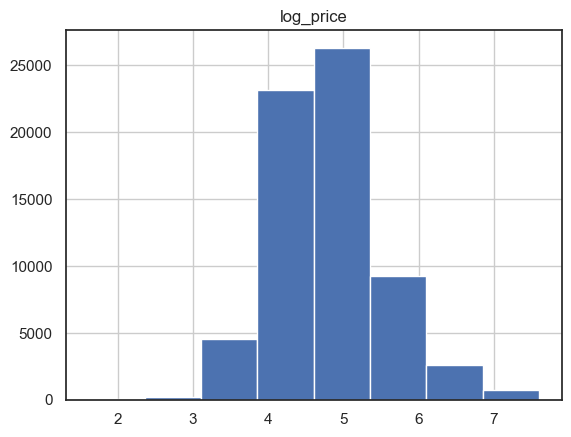

In [62]:
df.hist(column='log_price', bins =8 )

C:\Users\dilan\AppData\Local\Temp\ipykernel_38028\1393987990.py:7: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.hist(ax = ax)


array([[<AxesSubplot:title={'center':'log_price'}>,
        <AxesSubplot:title={'center':'accommodates'}>,
        <AxesSubplot:title={'center':'bathrooms'}>],
       [<AxesSubplot:title={'center':'latitude'}>,
        <AxesSubplot:title={'center':'longitude'}>,
        <AxesSubplot:title={'center':'number_of_reviews'}>],
       [<AxesSubplot:title={'center':'review_scores_rating'}>,
        <AxesSubplot:title={'center':'bedrooms'}>,
        <AxesSubplot:title={'center':'beds'}>]], dtype=object)

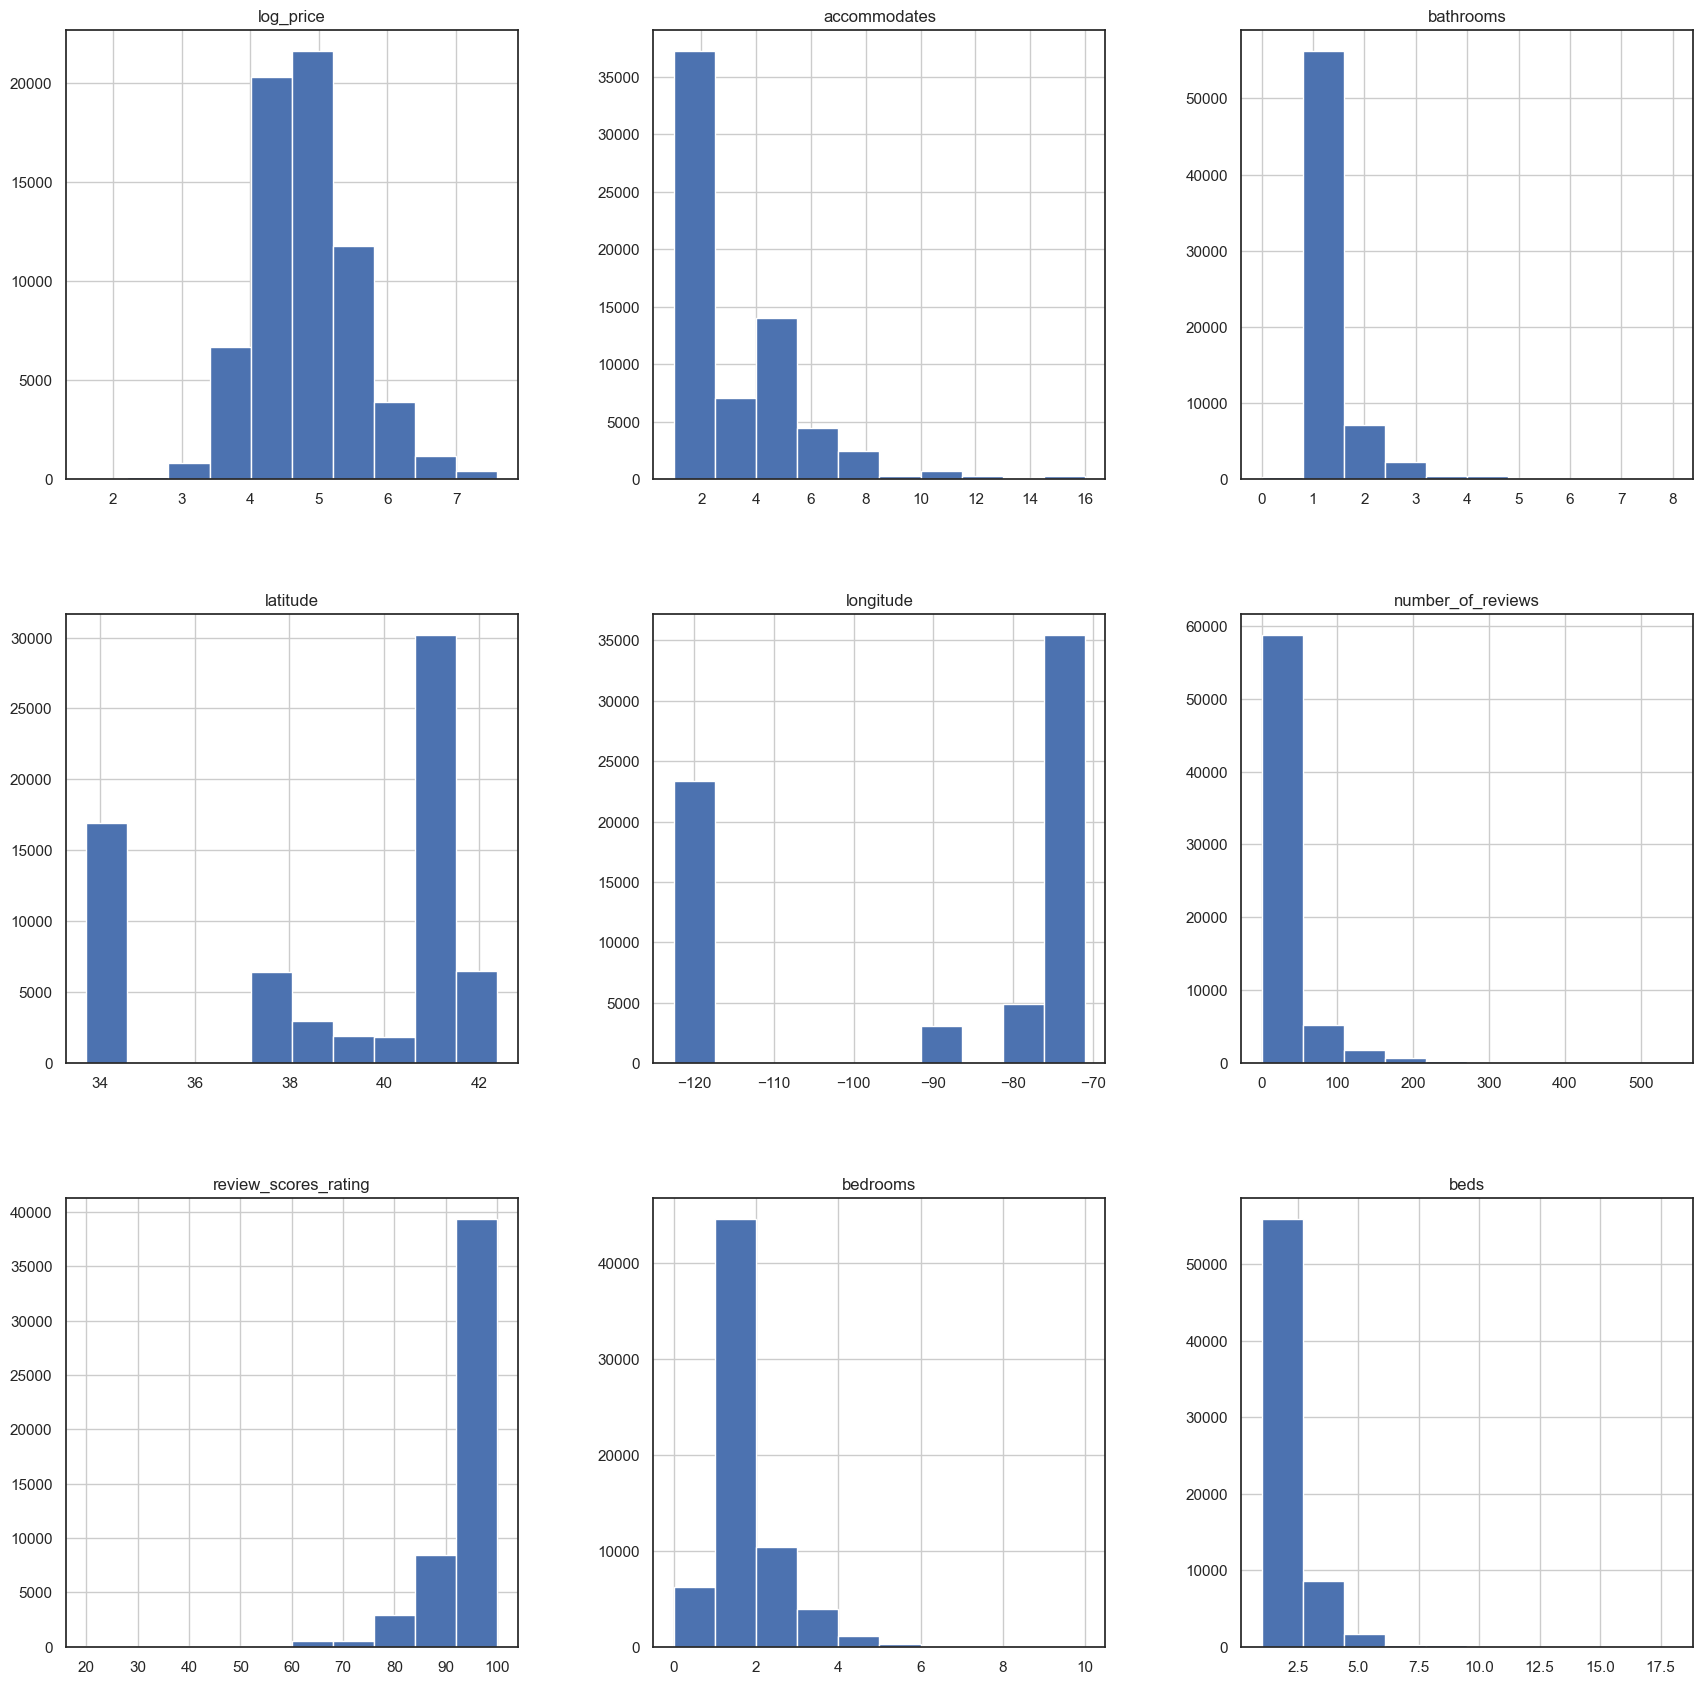

In [63]:
#Visualizar multiplas colunas e a sua distribuição



fig = plt.figure(figsize = (21,21))
ax = fig.gca()
df.hist(ax = ax)

In [1774]:
#Observar a relação entre as colunas discriminadas , e procurar padrões e correlações

#Criar lista e definir colunas a obervar
colunas=['Rooms','Price','Bedroom2', 'Bathroom','Car', 'Landsize','BuildingArea','YearBuilt']

#criar um pair grid plot entre as várias colunas em lista
#sns.pairplot(df[colunas])

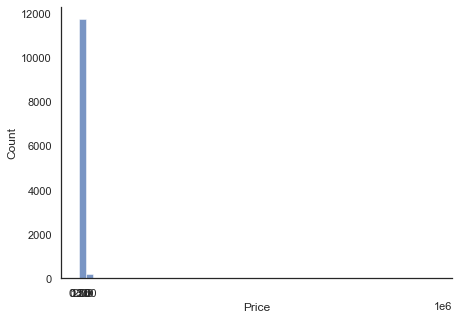

In [1775]:
#Observar a distribuição do valor do preço das casas

import matplotlib as mpl
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)

sns.histplot(
    df,
    x="Price",
    log_scale=False,
    linewidth=.5,
    bins=50
)

ax.xaxis.set_major_formatter(mpl.ticker.ScalarFormatter())
ax.set_xticks([250000, 500000, 1000000, 2000000, 3000000])

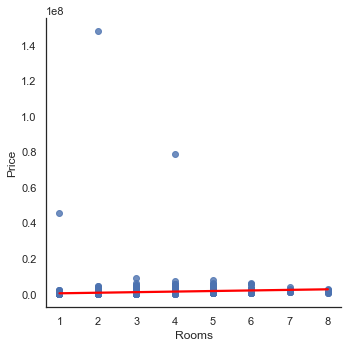

In [1776]:
#Procurar observar correlação entre Price e Rooms
sns.lmplot(x="Rooms", y="Price", data=df, line_kws={'color': 'red'})


<AxesSubplot:xlabel='BuildingArea', ylabel='Price'>

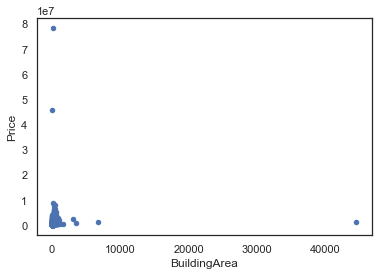

In [1777]:
#Procurar observar correlação entre Price e BuildingArea
df.plot.scatter(x = 'BuildingArea', y = 'Price' )

#podemos observar que existe alguma correlação entre as duas variáveis

# Exploração das Colunas presentes no Dataset:

In [1778]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11923 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         11923 non-null  object 
 1   Address        11923 non-null  object 
 2   Rooms          11923 non-null  float64
 3   Type           11923 non-null  object 
 4   Price          11923 non-null  float64
 5   Method         11923 non-null  object 
 6   SellerG        11923 non-null  object 
 7   Date           11923 non-null  object 
 8   Distance       11923 non-null  float64
 9   Postcode       11923 non-null  float64
 10  Bedroom2       11923 non-null  float64
 11  Bathroom       11923 non-null  float64
 12  Car            11876 non-null  float64
 13  Landsize       11923 non-null  float64
 14  BuildingArea   6254 non-null   float64
 15  YearBuilt      7179 non-null   float64
 16  CouncilArea    10723 non-null  object 
 17  Lattitude      11923 non-null  float64
 18  Longti

In [1779]:
#verificar a contagem de valores em falta
#podemos observar que os valores nulos nas colunas BuildingArea e YearBuilt representam cerca de ~ 50%
df.isnull().sum()

Suburb              0
Address             0
Rooms               0
Type                0
Price               0
Method              0
SellerG             0
Date                0
Distance            0
Postcode            0
Bedroom2            0
Bathroom            0
Car                47
Landsize            0
BuildingArea     5669
YearBuilt        4744
CouncilArea      1200
Lattitude           0
Longtitude          0
Regionname          0
Propertycount       0
dtype: int64

In [1780]:
#Observar o dataframe onde os carros são nulos
df[df['Car'].isnull()]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
12221,Ascot Vale,132 The Parade,3.0,h,985000.0,S,Brad,3/09/2017,4.3,3032.0,...,1.0,NaN,245.0,91.0,1945.0,NaN,-37.77215,144.91144,Western Metropolitan,6567.0
12259,Clifton Hill,34 Fenwick St,3.0,h,1436000.0,S,Jellis,3/09/2017,3.6,3068.0,...,2.0,NaN,123.0,128.0,1990.0,NaN,-37.78888,145.00036,Northern Metropolitan,2954.0
12320,Glen Waverley,19 Diamond Av,3.0,h,1370000.0,S,Fletchers,3/09/2017,16.7,3150.0,...,1.0,NaN,652.0,NaN,NaN,NaN,-37.87170,145.17267,Eastern Metropolitan,15321.0
12383,Port Melbourne,333 Princes St,3.0,h,1764000.0,S,Buxton,3/09/2017,3.5,3207.0,...,2.0,NaN,131.0,133.0,1900.0,NaN,-37.83509,144.94224,Southern Metropolitan,8648.0
12397,South Melbourne,303 Park St,2.0,h,1137000.0,S,hockingstuart,3/09/2017,1.9,3205.0,...,1.0,NaN,126.0,79.0,NaN,NaN,-37.83704,144.95606,Southern Metropolitan,5943.0
12462,Carlton,81 Princes St,2.0,h,800000.0,VB,Woodards,9/09/2017,1.6,3053.0,...,1.0,NaN,117.0,NaN,NaN,NaN,-37.79294,144.97283,Northern Metropolitan,6786.0
12474,Cremorne,22 Cubitt St,2.0,h,1200000.0,SP,Jellis,9/09/2017,2.4,3121.0,...,1.0,NaN,160.0,NaN,NaN,NaN,-37.82647,144.99264,Northern Metropolitan,1123.0
12489,Elwood,9 Mason Av,3.0,h,1400000.0,VB,Marshall,9/09/2017,7.2,3184.0,...,2.0,NaN,225.0,122.0,1890.0,NaN,-37.87614,144.99081,Southern Metropolitan,8989.0
12497,Fitzroy,101 Kerr St,3.0,h,1750000.0,VB,Jellis,9/09/2017,2.1,3065.0,...,1.0,NaN,152.0,NaN,NaN,NaN,-37.79662,144.97910,Northern Metropolitan,5825.0
12531,Hurstbridge,3 Milton Wy,3.0,h,600000.0,S,Mason,9/09/2017,26.1,3099.0,...,2.0,NaN,785.0,NaN,NaN,NaN,-37.63700,145.20166,Northern Victoria,1345.0


df.describe()

In [1781]:
#Procurar outliers
df.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,11923.000000,1.192300e+04,11923.000000,11923.000000,11923.000000,11923.000000,11876.000000,11923.000000,6254.000000,7179.000000,11923.000000,11923.000000,11923.000000
mean,2.932651,1.096858e+06,10.130546,3105.202214,2.910845,1.534429,1.609549,564.379435,153.706692,1964.939824,-37.809064,144.994744,7456.585591
std,0.957883,1.701394e+06,5.877200,91.183828,0.970122,0.694396,0.962999,4231.762690,577.015796,36.272060,0.079215,0.104100,4371.273601
min,1.000000,5.905000e+03,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1850.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,175.000000,93.000000,1940.000000,-37.856600,144.928910,4380.000000
50%,3.000000,9.000000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,441.000000,126.000000,1970.000000,-37.802200,144.999700,6567.000000
75%,3.000000,1.325000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.755910,145.057500,10331.000000
max,8.000000,1.480000e+08,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


In [1782]:
#antes de substituisr ou eliminar valores nulos, vamos elminiar os out liers com a metodologia IQR
#eliminar outliers

def remove_outlier(df_in, col_name):
    q1 = df_in[col_name].quantile(0.25)
    q3 = df_in[col_name].quantile(0.75)
    iqr = q3-q1 #Interquartile range
    fence_low  = q1-1.5*iqr
    fence_high = q3+1.5*iqr
    df_out = df_in.loc[(df_in[col_name] > fence_low) & (df_in[col_name] < fence_high)]
    return df_out


df = remove_outlier(df,'Price')
df = remove_outlier(df,'Rooms')
df = remove_outlier(df,'Distance')
df = remove_outlier(df,'Bedroom2')
df = remove_outlier(df,'Bathroom')
df = remove_outlier(df,'Car')
df = remove_outlier(df,'Landsize')
df = remove_outlier(df,'BuildingArea')

df = remove_outlier(df,'Propertycount')

In [1783]:
#Observar valores nulos
df.isnull().sum()

Suburb             0
Address            0
Rooms              0
Type               0
Price              0
Method             0
SellerG            0
Date               0
Distance           0
Postcode           0
Bedroom2           0
Bathroom           0
Car                0
Landsize           0
BuildingArea       0
YearBuilt        160
CouncilArea      376
Lattitude          0
Longtitude         0
Regionname         0
Propertycount      0
dtype: int64

In [1784]:
#Podemos observar que passamos a ter 4800 rows, inicialmente tinhamos 13580 rows
df

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
1,Abbotsford,25 Bloomburg St,2.0,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4.0,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019.0
6,Abbotsford,124 Yarra St,3.0,h,1876000.0,S,Nelson,7/05/2016,2.5,3067.0,...,2.0,0.0,245.0,210.0,1910.0,Yarra,-37.80240,144.99930,Northern Metropolitan,4019.0
7,Abbotsford,98 Charles St,2.0,h,1636000.0,S,Nelson,8/10/2016,2.5,3067.0,...,1.0,2.0,256.0,107.0,1890.0,Yarra,-37.80600,144.99540,Northern Metropolitan,4019.0
11,Abbotsford,40 Nicholson St,3.0,h,1350000.0,VB,Nelson,12/11/2016,2.5,3067.0,...,2.0,2.0,214.0,190.0,2005.0,Yarra,-37.80850,144.99640,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13571,Wantirna South,15 Mara Cl,4.0,h,1330000.0,S,Barry,26/08/2017,14.7,3152.0,...,2.0,2.0,717.0,191.0,1980.0,NaN,-37.86887,145.22116,Eastern Metropolitan,7082.0
13572,Watsonia,76 Kenmare St,2.0,h,650000.0,PI,Morrison,26/08/2017,14.5,3087.0,...,1.0,1.0,210.0,79.0,2006.0,NaN,-37.70657,145.07878,Northern Metropolitan,2329.0
13573,Werribee,5 Nuragi Ct,4.0,h,635000.0,S,hockingstuart,26/08/2017,14.7,3030.0,...,2.0,1.0,662.0,172.0,1980.0,NaN,-37.89327,144.64789,Western Metropolitan,16166.0
13576,Williamstown,77 Merrett Dr,3.0,h,1031000.0,SP,Williams,26/08/2017,6.8,3016.0,...,2.0,2.0,333.0,133.0,1995.0,NaN,-37.85927,144.87904,Western Metropolitan,6380.0


In [1785]:
#eliminar valores nulos menos de 20 %
df.dropna(subset=['CouncilArea'], inplace = True)


df.dropna(subset=['YearBuilt'], inplace = True)

In [1786]:
# ver  missing valeus. 
df.isnull().sum()


Suburb           0
Address          0
Rooms            0
Type             0
Price            0
Method           0
SellerG          0
Date             0
Distance         0
Postcode         0
Bedroom2         0
Bathroom         0
Car              0
Landsize         0
BuildingArea     0
YearBuilt        0
CouncilArea      0
Lattitude        0
Longtitude       0
Regionname       0
Propertycount    0
dtype: int64

In [1787]:
#Observamos que temos agora 4281 rows
df


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
1,Abbotsford,25 Bloomburg St,2.0,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.00,1900.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4.0,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.00,2014.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019.0
6,Abbotsford,124 Yarra St,3.0,h,1876000.0,S,Nelson,7/05/2016,2.5,3067.0,...,2.0,0.0,245.0,210.00,1910.0,Yarra,-37.80240,144.99930,Northern Metropolitan,4019.0
7,Abbotsford,98 Charles St,2.0,h,1636000.0,S,Nelson,8/10/2016,2.5,3067.0,...,1.0,2.0,256.0,107.00,1890.0,Yarra,-37.80600,144.99540,Northern Metropolitan,4019.0
11,Abbotsford,40 Nicholson St,3.0,h,1350000.0,VB,Nelson,12/11/2016,2.5,3067.0,...,2.0,2.0,214.0,190.00,2005.0,Yarra,-37.80850,144.99640,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12188,Tullamarine,9/200 Melrose Dr,2.0,u,300000.0,SP,Jason,29/07/2017,12.9,3043.0,...,1.0,1.0,0.0,66.32,1980.0,Hume,-37.69815,144.88019,Western Metropolitan,3296.0
12197,Werribee,18 Conquest Dr,4.0,h,645000.0,PI,hockingstuart,29/07/2017,14.7,3030.0,...,2.0,2.0,555.0,237.00,2002.0,Wyndham,-37.89359,144.66911,Western Metropolitan,16166.0
12203,Westmeadows,4 Pershore Ct,3.0,h,635000.0,S,Barry,29/07/2017,16.5,3049.0,...,2.0,1.0,691.0,177.00,1975.0,Hume,-37.68026,144.88468,Northern Metropolitan,2474.0
12206,Williamstown,75 Cecil St,3.0,h,1050000.0,VB,Williams,29/07/2017,6.8,3016.0,...,1.0,0.0,179.0,115.00,1890.0,Hobsons Bay,-37.86558,144.90474,Western Metropolitan,6380.0


<AxesSubplot:>

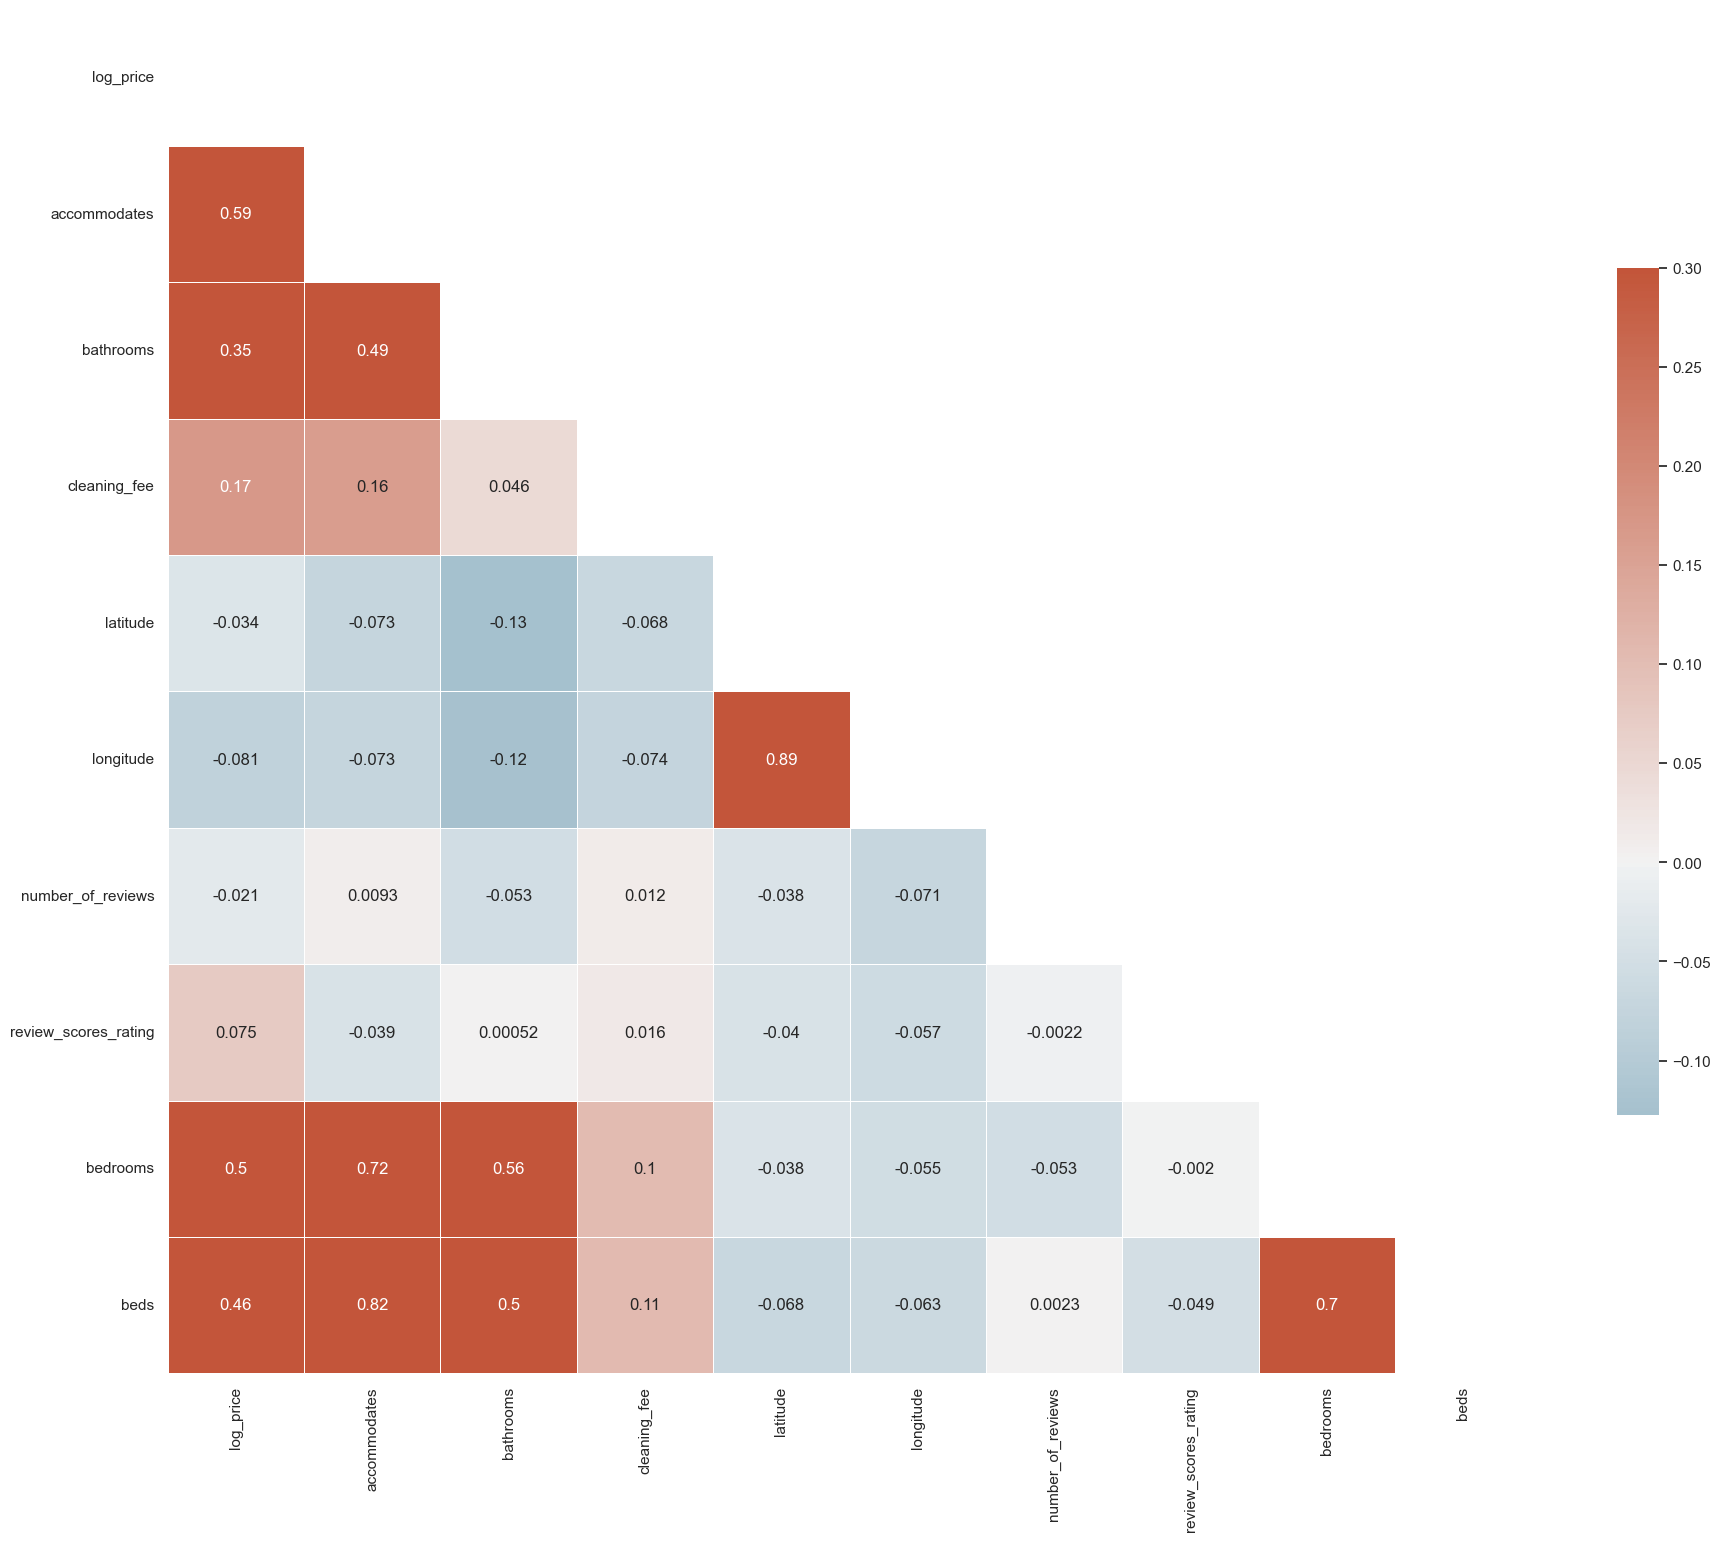

In [30]:
#vamos verificar a correlação
#observar a correlação 

sns.set_theme(style="white")
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(22, 22))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0, annot=True,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

[(50000.0, 5000000.0)]

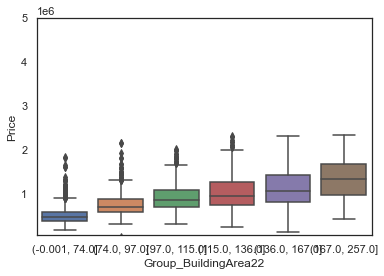

In [1789]:
#criar 'Group_BuildingArea' com 6 intervalos, utilizando o metodo QCUT() que divide em intervalos balanciados, no entanto cria a nova coluna como tipo de variavel categórico, e mais tarde esse tipo de variavel não faz a correlação da mesma forma que os numérico, logo aproveitamos o cut para encontrar o valor dos 6 intervalos, e por sua vez utilizamos uma função igual à anterior. 


df['Group_BuildingArea22'] = pd.qcut(x=df['BuildingArea'], q= 6)
         

#observar a distribuição 
ax2=sns.boxplot(x='Group_BuildingArea22', y="Price",
            data=df)
ax2.set(ylim=[50000, 5000000])



In [1790]:
#Discretization
#Distance

def DistanceDiscretization (row):
    if row['Distance'] <= 6.100000:
        return 0
    elif row['Distance'] > 6.100000 and row['Distance'] <= 9.200000:
        return 1
    elif row['Distance'] > 9.200000 and row['Distance'] <= 13.000000:
        return 2
    elif row['Distance'] > 13.000000:
        return 3

#Landsize

def LandsizeDiscretization (row):
    if row['Landsize'] <= 177.000000:
        return 0
    elif row['Landsize'] > 177.000000 and row['Landsize'] <= 440.000000:
        return 1
    elif row['Landsize'] > 440.000000 and row['Landsize'] <= 651.000000:
        return 2
    elif row['Landsize'] > 651.000000:
        return 3
#YearBuilt

def YearBuiltDiscretization (row):
    if row['YearBuilt'] <= 1940.0:
        return 0
    elif row['YearBuilt'] > 1940.0 and row['YearBuilt'] <= 1970.0:
        return 1
    elif row['YearBuilt'] > 1970.0 and row['YearBuilt'] <= 1999.0:
        return 2
    elif row['YearBuilt'] > 1999.0:
        return 3
    



    
    
def BuildingAreaDiscretization23 (row):
    if row['BuildingArea'] <= 75.0:
        return 0
    elif row['BuildingArea'] > 75.0 and row['BuildingArea'] <= 116.0: 
        return 1
    elif row['BuildingArea'] > 116.0 and row['BuildingArea'] <= 137.0:
        return 2
    elif row['BuildingArea'] > 137.0 and row['BuildingArea'] <= 168.833:
        return 3
    elif row['BuildingArea'] > 168.833 and row['BuildingArea'] <= 261.0:
        return 4
    elif row['BuildingArea'] > 261.0:
        return 5

    
    


    
    
df['Group_Distance'] = df.apply(DistanceDiscretization, axis = 1)
df['Group_Landsize'] = df.apply(LandsizeDiscretization, axis = 1)
df['Group_YearBuilt'] = df.apply(YearBuiltDiscretization, axis = 1)
df['Group_BuildingArea23'] = df.apply(BuildingAreaDiscretization23, axis = 1)



df.describe()



,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount,Group_Distance,Group_Landsize,Group_YearBuilt,Group_BuildingArea23
count,4281.000000,4.281000e+03,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000
mean,2.722962,9.443732e+05,8.990376,3092.786966,2.697734,1.446391,1.383789,334.555244,120.674364,1963.350619,-37.806207,144.983844,7144.057230,1.318150,1.148096,1.381453,1.804485
std,0.815079,4.366874e+05,4.461841,66.046376,0.809821,0.571918,0.699204,272.058262,47.844185,36.963959,0.066965,0.089502,3791.915695,1.089958,1.052379,1.129065,1.347493
min,1.000000,5.905000e+03,0.000000,3000.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1850.000000,-38.015960,144.633020,389.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,6.075000e+05,5.600000,3040.000000,2.000000,1.000000,1.000000,113.000000,86.000000,1940.000000,-37.852000,144.920900,4380.000000,0.000000,0.000000,0.000000,1.000000
50%,3.000000,8.540000e+05,8.400000,3074.000000,3.000000,1.000000,1.000000,288.000000,115.000000,1970.000000,-37.801000,144.988600,6543.000000,1.000000,1.000000,1.000000,1.000000
75%,3.000000,1.225000e+06,12.100000,3145.000000,3.000000,2.000000,2.000000,566.000000,150.000000,1999.000000,-37.760200,145.046810,9264.000000,2.000000,2.000000,2.000000,3.000000
max,4.000000,2.337000e+06,23.200000,3752.000000,4.000000,3.000000,3.000000,1235.000000,257.000000,2018.000000,-37.568830,145.293510,17496.000000,3.000000,3.000000,3.000000,4.000000


In [1791]:
#podemos observar que Group_BuildingArea23 já é numerico
df.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount,Group_Distance,Group_Landsize,Group_YearBuilt,Group_BuildingArea23
count,4281.000000,4.281000e+03,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000
mean,2.722962,9.443732e+05,8.990376,3092.786966,2.697734,1.446391,1.383789,334.555244,120.674364,1963.350619,-37.806207,144.983844,7144.057230,1.318150,1.148096,1.381453,1.804485
std,0.815079,4.366874e+05,4.461841,66.046376,0.809821,0.571918,0.699204,272.058262,47.844185,36.963959,0.066965,0.089502,3791.915695,1.089958,1.052379,1.129065,1.347493
min,1.000000,5.905000e+03,0.000000,3000.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1850.000000,-38.015960,144.633020,389.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,6.075000e+05,5.600000,3040.000000,2.000000,1.000000,1.000000,113.000000,86.000000,1940.000000,-37.852000,144.920900,4380.000000,0.000000,0.000000,0.000000,1.000000
50%,3.000000,8.540000e+05,8.400000,3074.000000,3.000000,1.000000,1.000000,288.000000,115.000000,1970.000000,-37.801000,144.988600,6543.000000,1.000000,1.000000,1.000000,1.000000
75%,3.000000,1.225000e+06,12.100000,3145.000000,3.000000,2.000000,2.000000,566.000000,150.000000,1999.000000,-37.760200,145.046810,9264.000000,2.000000,2.000000,2.000000,3.000000
max,4.000000,2.337000e+06,23.200000,3752.000000,4.000000,3.000000,3.000000,1235.000000,257.000000,2018.000000,-37.568830,145.293510,17496.000000,3.000000,3.000000,3.000000,4.000000


In [1793]:
#eliminar variaves com pouca correlação com o preço 

#eliminar as variaveis com menos de 0.10 de correlação ao preço.

df = df.drop(['Propertycount'], axis=1)
#drop colunas repetidas
df = df.drop(columns=['Group_BuildingArea22'])


In [1794]:
df.isnull().sum()

Suburb                  0
Address                 0
Rooms                   0
Type                    0
Price                   0
Method                  0
SellerG                 0
Date                    0
Distance                0
Postcode                0
Bedroom2                0
Bathroom                0
Car                     0
Landsize                0
BuildingArea            0
YearBuilt               0
CouncilArea             0
Lattitude               0
Longtitude              0
Regionname              0
Group_Distance          0
Group_Landsize          0
Group_YearBuilt         0
Group_BuildingArea23    0
dtype: int64

<AxesSubplot:>

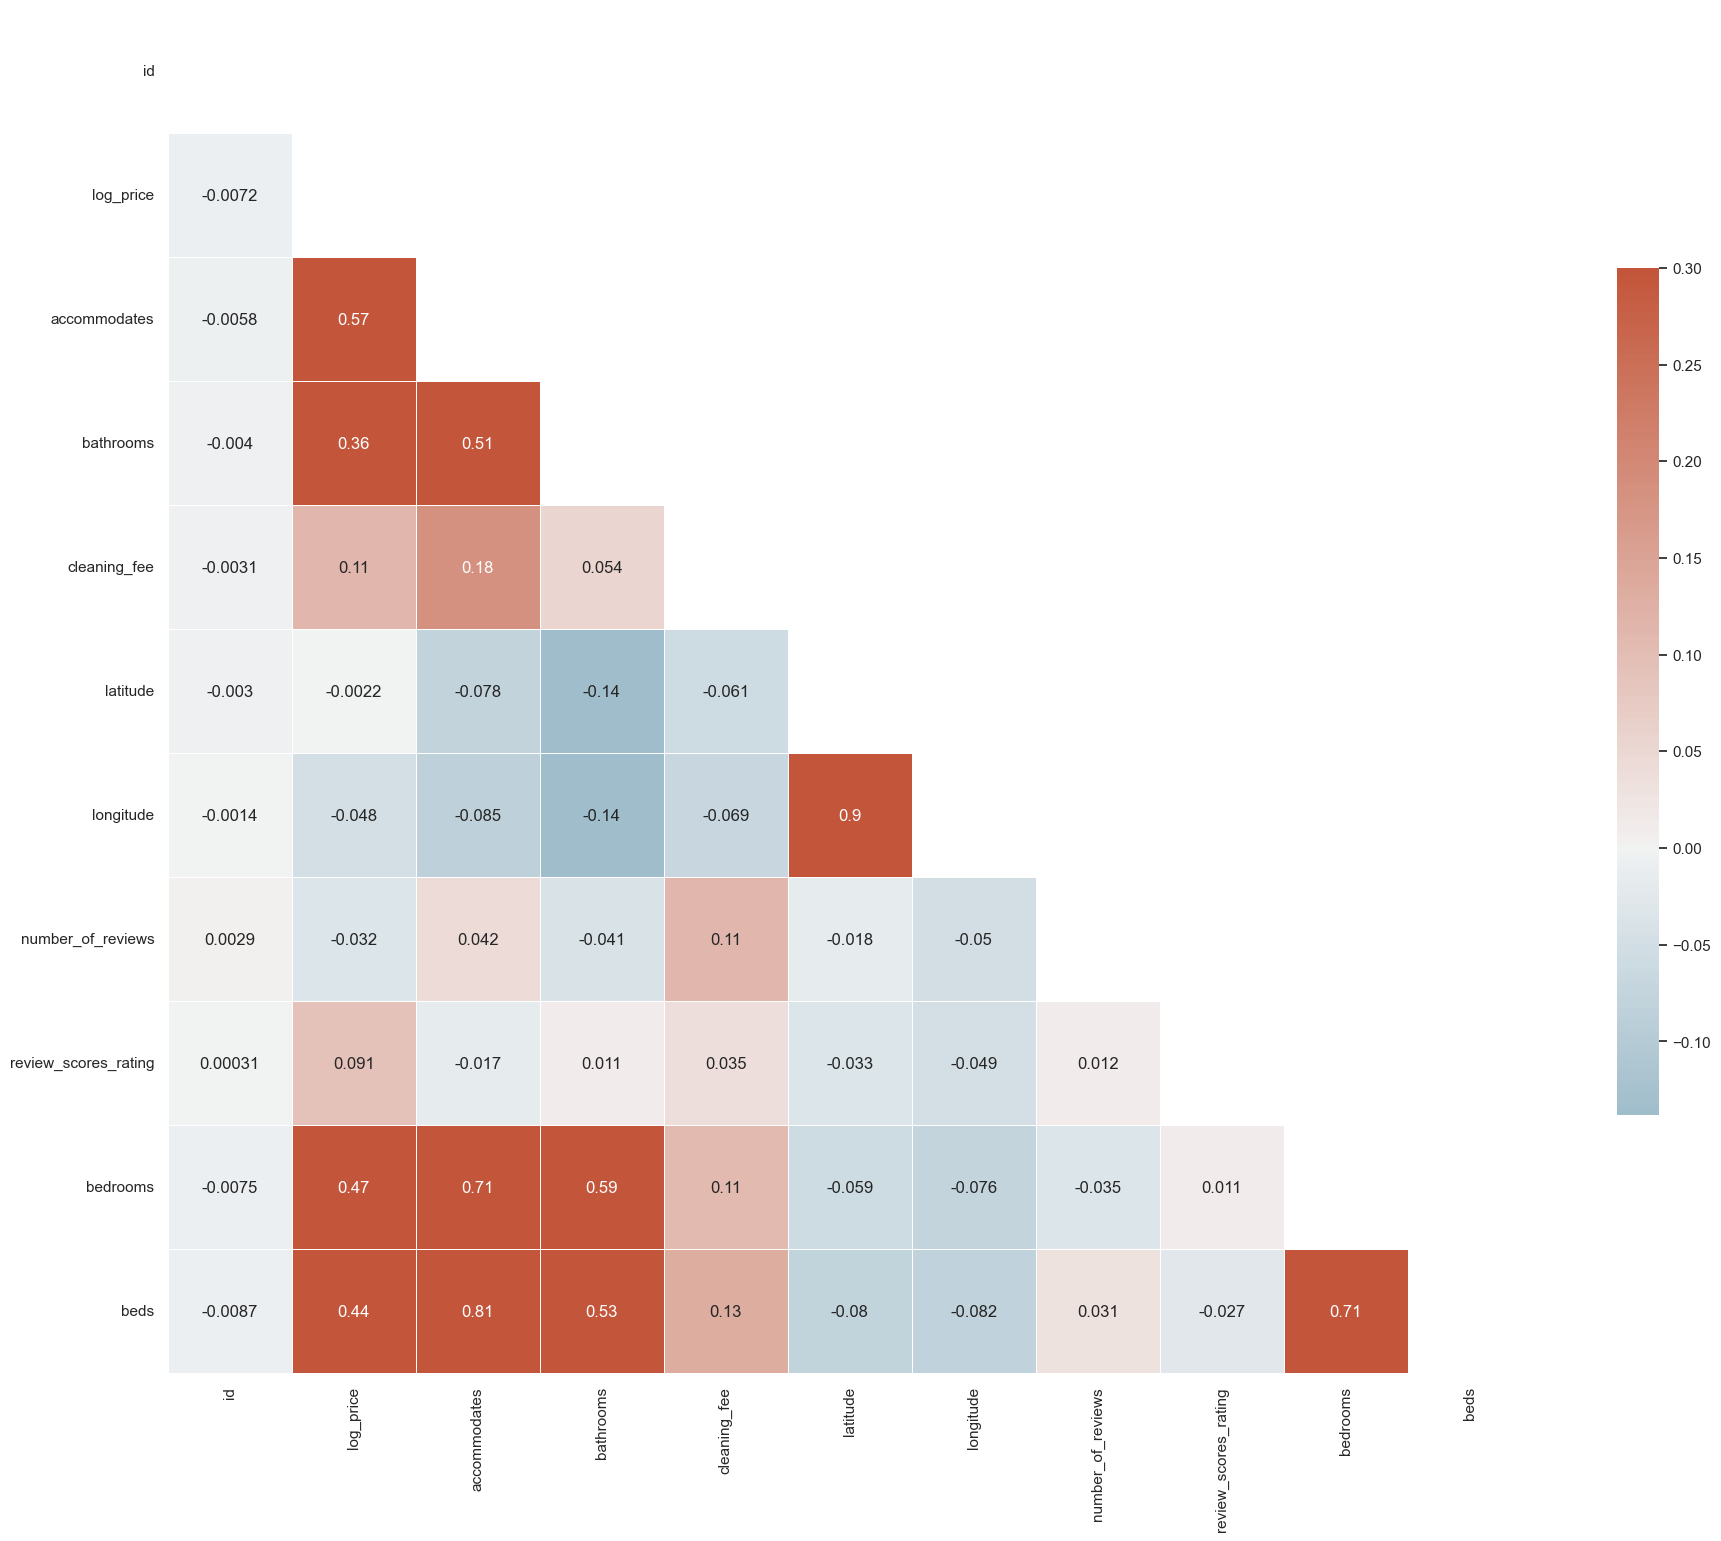

In [18]:
#observar a correlação 

sns.set_theme(style="white")
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(22, 22))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0, annot=True,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

<AxesSubplot:xlabel='Postcode', ylabel='Price'>

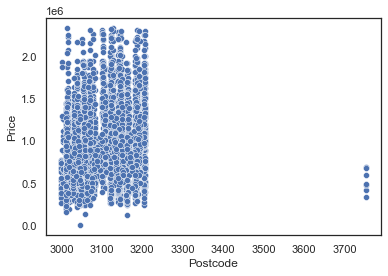

In [1797]:
#obsvervar correlação entre Postcode e price
sns.scatterplot(data=df, x='Postcode', y='Price')


<AxesSubplot:xlabel='Date', ylabel='Price'>

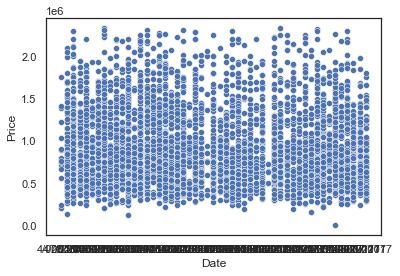

In [1798]:
#obsvervar correlação entre Postcode e price
sns.scatterplot(data=df, x='Date', y='Price')

In [1799]:
#eliminar counas com pouca correlação com o price
df = df.drop(['Address'], axis=1)
df = df.drop(['Date'], axis=1)





In [1800]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4281 entries, 1 to 12207
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Suburb                4281 non-null   object 
 1   Rooms                 4281 non-null   float64
 2   Type                  4281 non-null   object 
 3   Price                 4281 non-null   float64
 4   Method                4281 non-null   object 
 5   SellerG               4281 non-null   object 
 6   Distance              4281 non-null   float64
 7   Postcode              4281 non-null   float64
 8   Bedroom2              4281 non-null   float64
 9   Bathroom              4281 non-null   float64
 10  Car                   4281 non-null   float64
 11  Landsize              4281 non-null   float64
 12  BuildingArea          4281 non-null   float64
 13  YearBuilt             4281 non-null   float64
 14  CouncilArea           4281 non-null   object 
 15  Lattitude           

# CRIAR VARIÁVEIS DUMMIES

#Observar as futuras variáveis dummies


In [1801]:
#ver valores unicos de metodo 
df['Method'].unique()

array(['S', 'VB', 'PI', 'SP', 'SA'], dtype=object)

In [1802]:
df['Suburb'].unique()

array(['Abbotsford', 'Airport West', 'Albert Park', 'Alphington',
       'Altona', 'Altona North', 'Armadale', 'Ascot Vale', 'Ashburton',
       'Ashwood', 'Avondale Heights', 'Balaclava', 'Balwyn',
       'Balwyn North', 'Bentleigh', 'Bentleigh East', 'Box Hill',
       'Braybrook', 'Brighton', 'Brighton East', 'Brunswick',
       'Brunswick West', 'Bulleen', 'Burwood', 'Camberwell', 'Canterbury',
       'Carlton North', 'Carnegie', 'Caulfield', 'Caulfield North',
       'Caulfield South', 'Chadstone', 'Clifton Hill', 'Coburg',
       'Coburg North', 'Collingwood', 'Doncaster', 'Eaglemont',
       'Elsternwick', 'Elwood', 'Essendon', 'Essendon North', 'Fairfield',
       'Fitzroy', 'Fitzroy North', 'Flemington', 'Footscray', 'Glen Iris',
       'Glenroy', 'Gowanbrae', 'Hadfield', 'Hampton', 'Hampton East',
       'Hawthorn', 'Heidelberg Heights', 'Heidelberg West', 'Hughesdale',
       'Ivanhoe', 'Kealba', 'Keilor East', 'Kensington', 'Kew',
       'Kew East', 'Maidstone', 'Malvern', 

In [1803]:
#ver valores unicos de tipo de casa
df['Type'].unique()

array(['h', 'u', 't'], dtype=object)

In [1804]:
df["SellerG"].unique()

array(['Biggin', 'Nelson', 'Jellis', 'LITTLE', 'Kay', 'Collins',
       'Marshall', 'Brad', 'Maddison', 'Barry', 'Rendina', 'Harcourts',
       'hockingstuart', 'Greg', 'RT', 'Miles', 'Love', 'Barlow',
       'Village', 'Burnham', 'Compton', 'Jas', 'Williams', 'Hodges',
       'Raine', 'Alexkarbon', 'McDonald', 'Stockdale', 'Buxton',
       'Purplebricks', 'Fletchers', 'Ray', 'Noel', 'Tim', 'Moonee',
       'Edward', 'Gary', 'McGrath', 'Chisholm', 'Philip', 'Christopher',
       'Woodards', 'Bayside', 'C21', 'First', 'Beller', 'Matthew', 'Nick',
       'Lindellas', 'Allens', 'Sweeney', 'Bells', 'Trimson', 'YPA',
       "Tiernan's", 'Walshe', 'Dingle', 'RW', 'Chambers', 'Peter',
       'Grantham', 'hockingstuart/Advantage', "O'Donoghues", 'Ross',
       'Century', 'Property', 'Thomson', 'Australian', 'Anderson',
       'Rodney', 'Bekdon', 'Harrington', 'iTRAK', 'Nicholson', 'Re', 'RE',
       'Parkes', 'Scott', 'Pride', 'Owen', 'Morleys', 'Wilson', 'Frank',
       'Pagan', 'Paul', 'Red'

In [1805]:
#tornar dummie as colunas columns=["Regionname","SellerG",'Type','Suburb']
df = pd.get_dummies(df, columns=["Regionname",'Type','Method',"CouncilArea",'SellerG'], prefix=["Regionname",'Type','Method',"CouncilArea",'SellerG'])

In [1806]:
df = pd.get_dummies(df, columns=["Suburb"], prefix=['Suburb'])

In [1807]:

df.info(50)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4281 entries, 1 to 12207
Data columns (total 455 columns):
 #    Column                                 Dtype  
---   ------                                 -----  
 0    Rooms                                  float64
 1    Price                                  float64
 2    Distance                               float64
 3    Postcode                               float64
 4    Bedroom2                               float64
 5    Bathroom                               float64
 6    Car                                    float64
 7    Landsize                               float64
 8    BuildingArea                           float64
 9    YearBuilt                              float64
 10   Lattitude                              float64
 11   Longtitude                             float64
 12   Group_Distance                         int64  
 13   Group_Landsize                         int64  
 14   Group_YearBuilt                      

In [1808]:
df.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,...,Suburb_Werribee,Suburb_West Footscray,Suburb_West Melbourne,Suburb_Westmeadows,Suburb_Wheelers Hill,Suburb_Williamstown,Suburb_Williamstown North,Suburb_Windsor,Suburb_Yallambie,Suburb_Yarraville
count,4281.000000,4.281000e+03,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,...,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000
mean,2.722962,9.443732e+05,8.990376,3092.786966,2.697734,1.446391,1.383789,334.555244,120.674364,1963.350619,...,0.003504,0.009110,0.003504,0.000934,0.000234,0.009344,0.001635,0.004672,0.002336,0.016118
std,0.815079,4.366874e+05,4.461841,66.046376,0.809821,0.571918,0.699204,272.058262,47.844185,36.963959,...,0.059096,0.095022,0.059096,0.030557,0.015284,0.096221,0.040408,0.068199,0.048280,0.125943
min,1.000000,5.905000e+03,0.000000,3000.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1850.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,6.075000e+05,5.600000,3040.000000,2.000000,1.000000,1.000000,113.000000,86.000000,1940.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,8.540000e+05,8.400000,3074.000000,3.000000,1.000000,1.000000,288.000000,115.000000,1970.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.000000,1.225000e+06,12.100000,3145.000000,3.000000,2.000000,2.000000,566.000000,150.000000,1999.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,4.000000,2.337000e+06,23.200000,3752.000000,4.000000,3.000000,3.000000,1235.000000,257.000000,2018.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<Figure size 1440x1440 with 0 Axes>

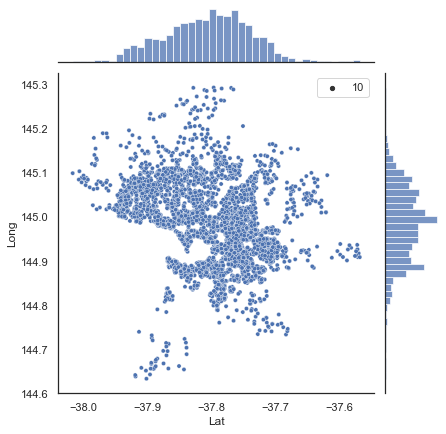

TypeError: 'module' object is not callable

In [1809]:
#ver  localização das habitações

plt.figure(figsize=(20,20))
sns.jointplot(x=df.Lattitude.values, y=df.Longtitude.values, size=10)
plt.ylabel('Long', fontsize=12)
plt.xlabel('Lat', fontsize=12)
plt.show()
plt1 = plt()
sns.despine

In [1]:
import folium
from folium import Choropleth, Circle, Marker
from folium.plugins import HeatMap, MarkerCluster

# find the row of the house which has the highest price
maxpr=df.loc[df['Price'].idxmax()]

# define a function to draw a basemap easily
def generateBaseMap(default_location=[47.5112, -122.257], default_zoom_start=9.4):
    base_map = folium.Map(location=default_location, control_scale=True, zoom_start=default_zoom_start)
    return base_map

df_copy = df.copy()
df_copy['count'] = 1
basemap = generateBaseMap()
# add carton position map
folium.TileLayer('cartodbpositron').add_to(basemap)
s=folium.FeatureGroup(name='icon').add_to(basemap)
# add a marker for the house which has the highest price
folium.Marker([maxpr['Lattitude'], maxpr['Longtitude']],popup='Highest Price: $'+str(format(maxpr['Price'],'.0f')),
              icon=folium.Icon(color='green')).add_to(s)
# add heatmap
HeatMap(data=df_copy[['Lattitude','Longtitude','count']].groupby(['Lattitude','Longtitude']).sum().reset_index().values.tolist(),
        radius=8,max_zoom=13,name='Heat Map').add_to(basemap)
folium.LayerControl(collapsed=False).add_to(basemap)
basemap

NameError: name 'df' is not defined

In [1811]:
#ter listagem do nome de todas as colunas
a = []
for column in df:
    a.append(str(column))
print(a)

['Rooms', 'Price', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Group_Distance', 'Group_Landsize', 'Group_YearBuilt', 'Group_BuildingArea23', 'Regionname_Eastern Metropolitan', 'Regionname_Northern Metropolitan', 'Regionname_Northern Victoria', 'Regionname_South-Eastern Metropolitan', 'Regionname_Southern Metropolitan', 'Regionname_Western Metropolitan', 'Type_h', 'Type_t', 'Type_u', 'Method_PI', 'Method_S', 'Method_SA', 'Method_SP', 'Method_VB', 'CouncilArea_Banyule', 'CouncilArea_Bayside', 'CouncilArea_Boroondara', 'CouncilArea_Brimbank', 'CouncilArea_Darebin', 'CouncilArea_Glen Eira', 'CouncilArea_Greater Dandenong', 'CouncilArea_Hobsons Bay', 'CouncilArea_Hume', 'CouncilArea_Kingston', 'CouncilArea_Knox', 'CouncilArea_Manningham', 'CouncilArea_Maribyrnong', 'CouncilArea_Maroondah', 'CouncilArea_Melbourne', 'CouncilArea_Melton', 'CouncilArea_Monash', 'CouncilArea_Moonee Valley', 'CouncilArea_Moreland', 'C

In [1812]:
df.info(30)


<class 'pandas.core.frame.DataFrame'>
Int64Index: 4281 entries, 1 to 12207
Data columns (total 455 columns):
 #    Column                                 Dtype  
---   ------                                 -----  
 0    Rooms                                  float64
 1    Price                                  float64
 2    Distance                               float64
 3    Postcode                               float64
 4    Bedroom2                               float64
 5    Bathroom                               float64
 6    Car                                    float64
 7    Landsize                               float64
 8    BuildingArea                           float64
 9    YearBuilt                              float64
 10   Lattitude                              float64
 11   Longtitude                             float64
 12   Group_Distance                         int64  
 13   Group_Landsize                         int64  
 14   Group_YearBuilt                      

In [1813]:
#!pip install folium

# Evaluation Metrics


*   MSE - Mean Squared Error
*   RMSE - Sqrt Mean Square Error
*   R Squared - Proportion of variance explained. That is: 100% means that the two variables are fully correlated.
*   Adjusted R Squared - It takes into consideration the number of variables used to explain and penalizes complex models

In [1814]:

from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn import metrics
from sklearn.model_selection import cross_val_score

train_data,test_data = train_test_split(df,train_size = 0.8,random_state=3)

evaluation = pd.DataFrame({'Model': [],
                           'Details':[],
                           'Root Mean Squared Error (RMSE)':[],
                           'R-squared (training)':[],
                           'Adjusted R-squared (training)':[],
                           'R-squared (test)':[],
                           'Adjusted R-squared (test)':[],
                           '5-Fold Cross Validation':[]})




# Multiple Linear Regression

In [1815]:
#Dividir o dataframe em test e train
train_data,test_data = train_test_split(df,train_size = 0.8,random_state=3)




#regressão linear multipla 

#após varios testes com features diferentes, as variáveis em lista foram as que tiveram melhor  R^2
regr = linear_model.LinearRegression()
X_train = np.array(train_data[['Rooms','Bedroom2', 'Bathroom','Postcode', 'Distance','YearBuilt','BuildingArea','Group_BuildingArea23','Group_YearBuilt','Group_Landsize','Lattitude','Longtitude','Landsize','Regionname_Northern Metropolitan' ,'Regionname_Southern Metropolitan','Type_h','Type_u']])
y_train = np.array(train_data['Price'])
X_test = np.array(test_data[['Rooms','Bedroom2', 'Bathroom','Postcode', 'Distance','YearBuilt','BuildingArea','Group_BuildingArea23','Group_YearBuilt','Group_Landsize','Lattitude','Longtitude','Landsize','Regionname_Northern Metropolitan' ,'Regionname_Southern Metropolitan','Type_h','Type_u']])
y_test = np.array(test_data['Price'])
regr.fit(X_train,y_train)




LinearRegression()

In [1816]:
print('Coefficients: ', regr.coef_)

Coefficients:  [ 3.15019696e+04  5.73557764e+04  6.08837150e+04  1.23732243e+02
 -3.78671725e+04 -3.12694933e+03  2.49388489e+03  1.96972353e+04
  2.98442664e+04  2.71762396e+04 -9.99779289e+05  1.04298925e+06
  6.88692524e+01 -2.69986176e+04  8.32500784e+04  8.98472473e+04
 -1.65391558e+05]


The coefficient estimates for Ordinary Least Squares rely on the independence of the features

In [1817]:
train_pred = regr.predict(X_train)
mse_train = metrics.mean_squared_error(y_train, train_pred)
print(np.sqrt(mse_train))

224979.1120829646


In [1818]:
test_pred = regr.predict(X_test)
mse_test = metrics.mean_squared_error(y_test, test_pred)
print(np.sqrt(mse_test))

227937.31054307905


In [1819]:
print(regr.score(X_train, y_train))

0.7292990254292078


Quanto maior o R² (resultado da função .score()), mais explicativo é o modelo linear, ou seja, melhor ele se ajusta à amostra. Por exemplo, um R² = 0,8234 significa que o modelo linear explica 82,34% da variância da variável dependente a partir do regressores (variáveis independentes) incluídas naquele modelo linear.

In [1820]:
print(regr.score(X_test, y_test))

0.7468975144549802


Testes a fazer: 
- Todas as features
- Feature engineering -> idade da casa, idade renovação, idade em bins

In [1821]:
from sklearn.preprocessing import PolynomialFeatures

#após varios testes com features diferentes, estas são as que têm melhor  R^2
features=['Rooms','Bedroom2','Bathroom','Postcode','Distance', 'YearBuilt','BuildingArea','Lattitude','Longtitude','Group_Landsize','Regionname_Northern Metropolitan' ,'Regionname_Southern Metropolitan','Type_h','Type_u']
polyfeat = PolynomialFeatures(degree=2)
#X_allpoly = polyfeat.fit_transform(df[features])
X_trainpoly = polyfeat.fit_transform(train_data[features])
X_testpoly = polyfeat.fit_transform(test_data[features])
poly = linear_model.LinearRegression().fit(X_trainpoly, train_data['Price'])

In [1822]:
pred1 = poly.predict(X_testpoly)
mse_train = metrics.mean_squared_error(y_test, pred1)
print(np.sqrt(mse_train))

197364.83448342624


In [1823]:
print(poly.score(X_testpoly, y_test))

0.8102398040373169


algoritmo ensemble.GradientBoostingRegressor 

In [1824]:
X_train2 = np.array(train_data[['Rooms', 'Price', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Group_Distance', 'Group_Landsize', 'Group_YearBuilt', 'Group_BuildingArea23', 'Regionname_Eastern Metropolitan', 'Regionname_Northern Metropolitan', 'Regionname_Northern Victoria', 'Regionname_South-Eastern Metropolitan', 'Regionname_Southern Metropolitan', 'Regionname_Western Metropolitan', 'Type_h', 'Type_t', 'Type_u', 'Method_PI', 'Method_S', 'Method_SA', 'Method_SP', 'Method_VB', 'CouncilArea_Banyule', 'CouncilArea_Bayside', 'CouncilArea_Boroondara', 'CouncilArea_Brimbank', 'CouncilArea_Darebin', 'CouncilArea_Glen Eira', 'CouncilArea_Greater Dandenong', 'CouncilArea_Hobsons Bay', 'CouncilArea_Hume', 'CouncilArea_Kingston', 'CouncilArea_Knox', 'CouncilArea_Manningham', 'CouncilArea_Maribyrnong', 'CouncilArea_Maroondah', 'CouncilArea_Melbourne', 'CouncilArea_Melton', 'CouncilArea_Monash', 'CouncilArea_Moonee Valley', 'CouncilArea_Moreland', 'CouncilArea_Nillumbik', 'CouncilArea_Port Phillip', 'CouncilArea_Stonnington', 'CouncilArea_Whitehorse', 'CouncilArea_Whittlesea', 'CouncilArea_Wyndham', 'CouncilArea_Yarra', 'SellerG_@Realty', "SellerG_Abercromby's", 'SellerG_Alexkarbon', 'SellerG_Allens', 'SellerG_Anderson', 'SellerG_Ascend', 'SellerG_Australian', 'SellerG_Barlow', 'SellerG_Barry', 'SellerG_Bayside', 'SellerG_Bekdon', 'SellerG_Beller', 'SellerG_Bells', 'SellerG_Besser', 'SellerG_Biggin', 'SellerG_Brad', 'SellerG_Buckingham', 'SellerG_Burnham', 'SellerG_Buxton', 'SellerG_Buxton/Find', 'SellerG_C21', 'SellerG_Caine', 'SellerG_Carter', 'SellerG_Castran', 'SellerG_Cayzer', 'SellerG_Century', 'SellerG_Chambers', 'SellerG_Charlton', 'SellerG_Chisholm', 'SellerG_Christopher', 'SellerG_Clairmont', 'SellerG_Collins', 'SellerG_Compton', 'SellerG_Considine', 'SellerG_Crane', "SellerG_D'Aprano", 'SellerG_Darren', 'SellerG_Dingle', 'SellerG_Dixon', 'SellerG_Domain', 'SellerG_Douglas', 'SellerG_Edward', 'SellerG_Eview', 'SellerG_FN', 'SellerG_First', 'SellerG_Fletchers', 'SellerG_Frank', 'SellerG_GL', 'SellerG_Galldon', 'SellerG_Gardiner', 'SellerG_Gary', 'SellerG_Geoff', 'SellerG_Grantham', 'SellerG_Greg', 'SellerG_Gunn&Co', 'SellerG_HAR', 'SellerG_Hall', 'SellerG_Harcourts', 'SellerG_Harrington', 'SellerG_Haughton', 'SellerG_Hayeswinckle', 'SellerG_Hodges', 'SellerG_Holland', 'SellerG_Homes', 'SellerG_Hoskins', 'SellerG_Hunter', 'SellerG_J', 'SellerG_JMRE', 'SellerG_Jas', 'SellerG_Jason', 'SellerG_Jellis', 'SellerG_Johnston', 'SellerG_Kay', 'SellerG_Ken', 'SellerG_LITTLE', 'SellerG_LJ', 'SellerG_Leyton', 'SellerG_Lindellas', 'SellerG_Love', 'SellerG_MICM', 'SellerG_Maddison', 'SellerG_Mandy', 'SellerG_Marshall', 'SellerG_Mason', 'SellerG_Matthew', 'SellerG_McDonald', 'SellerG_McGrath', 'SellerG_Melbourne', 'SellerG_Miles', 'SellerG_Millership', 'SellerG_Moonee', 'SellerG_Morleys', 'SellerG_Morrison', 'SellerG_Naison', 'SellerG_Nelson', 'SellerG_New', 'SellerG_Nicholson', 'SellerG_Nick', 'SellerG_Noel', "SellerG_O'Brien", "SellerG_O'Donoghues", 'SellerG_Oak', 'SellerG_Obrien', 'SellerG_One', 'SellerG_Owen', 'SellerG_Pagan', 'SellerG_Parkes', 'SellerG_Paul', 'SellerG_Peter', 'SellerG_Philip', 'SellerG_Pride', 'SellerG_Prime', 'SellerG_Prof.', 'SellerG_Property', 'SellerG_Prowse', 'SellerG_Purplebricks', 'SellerG_R&H', 'SellerG_RE', 'SellerG_RT', 'SellerG_RW', 'SellerG_Raine', 'SellerG_Raine&Horne', 'SellerG_Ray', 'SellerG_Re', 'SellerG_Real', 'SellerG_Red', 'SellerG_Redina', 'SellerG_Reed', 'SellerG_Reliance', 'SellerG_Rendina', 'SellerG_Ristic', 'SellerG_Rodney', 'SellerG_Ross', 'SellerG_Rounds', 'SellerG_S&L', 'SellerG_Schroeder', 'SellerG_Scott', 'SellerG_Sell', "SellerG_Sotheby's", 'SellerG_Stockdale', 'SellerG_Sweeney', 'SellerG_Sweeney/Advantage', 'SellerG_TRUE', 'SellerG_Thomson', "SellerG_Tiernan's", 'SellerG_Tim', 'SellerG_Trimson', 'SellerG_Triwest', 'SellerG_VICPROP', 'SellerG_Victory', 'SellerG_Village', 'SellerG_W.B.', 'SellerG_WHITEFOX', 'SellerG_Walsh', 'SellerG_Walshe', 'SellerG_Weston', 'SellerG_Westside', 'SellerG_Whiting', 'SellerG_William', 'SellerG_Williams', 'SellerG_Wilson', 'SellerG_Win', 'SellerG_Wood', 'SellerG_Woodards', 'SellerG_YPA', 'SellerG_Zahn', 'SellerG_hockingstuart', 'SellerG_hockingstuart/Advantage', 'SellerG_hockingstuart/Village', 'SellerG_iOne', 'SellerG_iSell', 'SellerG_iTRAK', 'Suburb_Abbotsford', 'Suburb_Aberfeldie', 'Suburb_Airport West', 'Suburb_Albanvale', 'Suburb_Albert Park', 'Suburb_Albion', 'Suburb_Alphington', 'Suburb_Altona', 'Suburb_Altona Meadows', 'Suburb_Altona North', 'Suburb_Ardeer', 'Suburb_Armadale', 'Suburb_Ascot Vale', 'Suburb_Ashburton', 'Suburb_Ashwood', 'Suburb_Aspendale', 'Suburb_Avondale Heights', 'Suburb_Balaclava', 'Suburb_Balwyn', 'Suburb_Balwyn North', 'Suburb_Bayswater', 'Suburb_Bayswater North', 'Suburb_Beaumaris', 'Suburb_Bellfield', 'Suburb_Bentleigh', 'Suburb_Bentleigh East', 'Suburb_Black Rock', 'Suburb_Blackburn', 'Suburb_Blackburn North', 'Suburb_Blackburn South', 'Suburb_Box Hill', 'Suburb_Braybrook', 'Suburb_Briar Hill', 'Suburb_Brighton', 'Suburb_Brighton East', 'Suburb_Broadmeadows', 'Suburb_Brooklyn', 'Suburb_Brunswick', 'Suburb_Brunswick East', 'Suburb_Brunswick West', 'Suburb_Bulleen', 'Suburb_Bundoora', 'Suburb_Burnley', 'Suburb_Burnside Heights', 'Suburb_Burwood', 'Suburb_Burwood East', 'Suburb_Cairnlea', 'Suburb_Camberwell', 'Suburb_Canterbury', 'Suburb_Carlton', 'Suburb_Carlton North', 'Suburb_Carnegie', 'Suburb_Caroline Springs', 'Suburb_Caulfield', 'Suburb_Caulfield North', 'Suburb_Caulfield South', 'Suburb_Chadstone', 'Suburb_Cheltenham', 'Suburb_Clayton', 'Suburb_Clifton Hill', 'Suburb_Coburg', 'Suburb_Coburg North', 'Suburb_Collingwood', 'Suburb_Craigieburn', 'Suburb_Cremorne', 'Suburb_Croydon', 'Suburb_Croydon Hills', 'Suburb_Croydon North', 'Suburb_Deepdene', 'Suburb_Deer Park', 'Suburb_Delahey', 'Suburb_Derrimut', 'Suburb_Diamond Creek', 'Suburb_Dingley Village', 'Suburb_Doncaster', 'Suburb_Doncaster East', 'Suburb_Donvale', 'Suburb_Eaglemont', 'Suburb_East Melbourne', 'Suburb_Elsternwick', 'Suburb_Eltham', 'Suburb_Eltham North', 'Suburb_Elwood', 'Suburb_Epping', 'Suburb_Essendon', 'Suburb_Essendon North', 'Suburb_Essendon West', 'Suburb_Fairfield', 'Suburb_Fawkner', 'Suburb_Fitzroy', 'Suburb_Fitzroy North', 'Suburb_Flemington', 'Suburb_Footscray', 'Suburb_Forest Hill', 'Suburb_Gardenvale', 'Suburb_Gladstone Park', 'Suburb_Glen Huntly', 'Suburb_Glen Iris', 'Suburb_Glen Waverley', 'Suburb_Glenroy', 'Suburb_Gowanbrae', 'Suburb_Greensborough', 'Suburb_Greenvale', 'Suburb_Hadfield', 'Suburb_Hampton', 'Suburb_Hampton East', 'Suburb_Hawthorn', 'Suburb_Hawthorn East', 'Suburb_Heathmont', 'Suburb_Heidelberg', 'Suburb_Heidelberg Heights', 'Suburb_Heidelberg West', 'Suburb_Highett', 'Suburb_Hillside', 'Suburb_Hoppers Crossing', 'Suburb_Hughesdale', 'Suburb_Huntingdale', 'Suburb_Ivanhoe', 'Suburb_Ivanhoe East', 'Suburb_Jacana', 'Suburb_Kealba', 'Suburb_Keilor', 'Suburb_Keilor Downs', 'Suburb_Keilor East', 'Suburb_Keilor Park', 'Suburb_Kensington', 'Suburb_Kew', 'Suburb_Kew East', 'Suburb_Kings Park', 'Suburb_Kingsbury', 'Suburb_Kingsville', 'Suburb_Lalor', 'Suburb_Lower Plenty', 'Suburb_Maidstone', 'Suburb_Malvern', 'Suburb_Malvern East', 'Suburb_Maribyrnong', 'Suburb_McKinnon', 'Suburb_Meadow Heights', 'Suburb_Melbourne', 'Suburb_Mentone', 'Suburb_Middle Park', 'Suburb_Mill Park', 'Suburb_Mitcham', 'Suburb_Mont Albert', 'Suburb_Montmorency', 'Suburb_Moonee Ponds', 'Suburb_Moorabbin', 'Suburb_Mordialloc', 'Suburb_Mount Waverley', 'Suburb_Mulgrave', 'Suburb_Murrumbeena', 'Suburb_Newport', 'Suburb_Niddrie', 'Suburb_Noble Park', 'Suburb_North Melbourne', 'Suburb_Northcote', 'Suburb_Notting Hill', 'Suburb_Nunawading', 'Suburb_Oak Park', 'Suburb_Oakleigh', 'Suburb_Oakleigh East', 'Suburb_Oakleigh South', 'Suburb_Ormond', 'Suburb_Parkdale', 'Suburb_Parkville', 'Suburb_Pascoe Vale', 'Suburb_Point Cook', 'Suburb_Port Melbourne', 'Suburb_Prahran', 'Suburb_Preston', 'Suburb_Princes Hill', 'Suburb_Richmond', 'Suburb_Ringwood', 'Suburb_Ringwood East', 'Suburb_Ringwood North', 'Suburb_Ripponlea', 'Suburb_Rosanna', 'Suburb_Roxburgh Park', 'Suburb_Sandringham', 'Suburb_Scoresby', 'Suburb_Seddon', 'Suburb_South Kingsville', 'Suburb_South Melbourne', 'Suburb_South Morang', 'Suburb_South Yarra', 'Suburb_Southbank', 'Suburb_Spotswood', 'Suburb_Springvale', 'Suburb_Springvale South', 'Suburb_St Albans', 'Suburb_St Kilda', 'Suburb_Strathmore', 'Suburb_Strathmore Heights', 'Suburb_Sunshine', 'Suburb_Sunshine North', 'Suburb_Sunshine West', 'Suburb_Surrey Hills', 'Suburb_Sydenham', 'Suburb_Tarneit', 'Suburb_Taylors Hill', 'Suburb_Taylors Lakes', 'Suburb_Templestowe', 'Suburb_Templestowe Lower', 'Suburb_Thomastown', 'Suburb_Thornbury', 'Suburb_Toorak', 'Suburb_Travancore', 'Suburb_Truganina', 'Suburb_Tullamarine', 'Suburb_Vermont', 'Suburb_Vermont South', 'Suburb_Viewbank', 'Suburb_Wantirna South', 'Suburb_Warrandyte', 'Suburb_Watsonia', 'Suburb_Watsonia North', 'Suburb_Werribee', 'Suburb_West Footscray', 'Suburb_West Melbourne', 'Suburb_Westmeadows', 'Suburb_Wheelers Hill', 'Suburb_Williamstown', 'Suburb_Williamstown North', 'Suburb_Windsor', 'Suburb_Yallambie', 'Suburb_Yarraville']])
y_train2 = np.array(train_data['Price'])
X_test2 = np.array(train_data[['Rooms', 'Price', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Group_Distance', 'Group_Landsize', 'Group_YearBuilt', 'Group_BuildingArea23', 'Regionname_Eastern Metropolitan', 'Regionname_Northern Metropolitan', 'Regionname_Northern Victoria', 'Regionname_South-Eastern Metropolitan', 'Regionname_Southern Metropolitan', 'Regionname_Western Metropolitan', 'Type_h', 'Type_t', 'Type_u', 'Method_PI', 'Method_S', 'Method_SA', 'Method_SP', 'Method_VB', 'CouncilArea_Banyule', 'CouncilArea_Bayside', 'CouncilArea_Boroondara', 'CouncilArea_Brimbank', 'CouncilArea_Darebin', 'CouncilArea_Glen Eira', 'CouncilArea_Greater Dandenong', 'CouncilArea_Hobsons Bay', 'CouncilArea_Hume', 'CouncilArea_Kingston', 'CouncilArea_Knox', 'CouncilArea_Manningham', 'CouncilArea_Maribyrnong', 'CouncilArea_Maroondah', 'CouncilArea_Melbourne', 'CouncilArea_Melton', 'CouncilArea_Monash', 'CouncilArea_Moonee Valley', 'CouncilArea_Moreland', 'CouncilArea_Nillumbik', 'CouncilArea_Port Phillip', 'CouncilArea_Stonnington', 'CouncilArea_Whitehorse', 'CouncilArea_Whittlesea', 'CouncilArea_Wyndham', 'CouncilArea_Yarra', 'SellerG_@Realty', "SellerG_Abercromby's", 'SellerG_Alexkarbon', 'SellerG_Allens', 'SellerG_Anderson', 'SellerG_Ascend', 'SellerG_Australian', 'SellerG_Barlow', 'SellerG_Barry', 'SellerG_Bayside', 'SellerG_Bekdon', 'SellerG_Beller', 'SellerG_Bells', 'SellerG_Besser', 'SellerG_Biggin', 'SellerG_Brad', 'SellerG_Buckingham', 'SellerG_Burnham', 'SellerG_Buxton', 'SellerG_Buxton/Find', 'SellerG_C21', 'SellerG_Caine', 'SellerG_Carter', 'SellerG_Castran', 'SellerG_Cayzer', 'SellerG_Century', 'SellerG_Chambers', 'SellerG_Charlton', 'SellerG_Chisholm', 'SellerG_Christopher', 'SellerG_Clairmont', 'SellerG_Collins', 'SellerG_Compton', 'SellerG_Considine', 'SellerG_Crane', "SellerG_D'Aprano", 'SellerG_Darren', 'SellerG_Dingle', 'SellerG_Dixon', 'SellerG_Domain', 'SellerG_Douglas', 'SellerG_Edward', 'SellerG_Eview', 'SellerG_FN', 'SellerG_First', 'SellerG_Fletchers', 'SellerG_Frank', 'SellerG_GL', 'SellerG_Galldon', 'SellerG_Gardiner', 'SellerG_Gary', 'SellerG_Geoff', 'SellerG_Grantham', 'SellerG_Greg', 'SellerG_Gunn&Co', 'SellerG_HAR', 'SellerG_Hall', 'SellerG_Harcourts', 'SellerG_Harrington', 'SellerG_Haughton', 'SellerG_Hayeswinckle', 'SellerG_Hodges', 'SellerG_Holland', 'SellerG_Homes', 'SellerG_Hoskins', 'SellerG_Hunter', 'SellerG_J', 'SellerG_JMRE', 'SellerG_Jas', 'SellerG_Jason', 'SellerG_Jellis', 'SellerG_Johnston', 'SellerG_Kay', 'SellerG_Ken', 'SellerG_LITTLE', 'SellerG_LJ', 'SellerG_Leyton', 'SellerG_Lindellas', 'SellerG_Love', 'SellerG_MICM', 'SellerG_Maddison', 'SellerG_Mandy', 'SellerG_Marshall', 'SellerG_Mason', 'SellerG_Matthew', 'SellerG_McDonald', 'SellerG_McGrath', 'SellerG_Melbourne', 'SellerG_Miles', 'SellerG_Millership', 'SellerG_Moonee', 'SellerG_Morleys', 'SellerG_Morrison', 'SellerG_Naison', 'SellerG_Nelson', 'SellerG_New', 'SellerG_Nicholson', 'SellerG_Nick', 'SellerG_Noel', "SellerG_O'Brien", "SellerG_O'Donoghues", 'SellerG_Oak', 'SellerG_Obrien', 'SellerG_One', 'SellerG_Owen', 'SellerG_Pagan', 'SellerG_Parkes', 'SellerG_Paul', 'SellerG_Peter', 'SellerG_Philip', 'SellerG_Pride', 'SellerG_Prime', 'SellerG_Prof.', 'SellerG_Property', 'SellerG_Prowse', 'SellerG_Purplebricks', 'SellerG_R&H', 'SellerG_RE', 'SellerG_RT', 'SellerG_RW', 'SellerG_Raine', 'SellerG_Raine&Horne', 'SellerG_Ray', 'SellerG_Re', 'SellerG_Real', 'SellerG_Red', 'SellerG_Redina', 'SellerG_Reed', 'SellerG_Reliance', 'SellerG_Rendina', 'SellerG_Ristic', 'SellerG_Rodney', 'SellerG_Ross', 'SellerG_Rounds', 'SellerG_S&L', 'SellerG_Schroeder', 'SellerG_Scott', 'SellerG_Sell', "SellerG_Sotheby's", 'SellerG_Stockdale', 'SellerG_Sweeney', 'SellerG_Sweeney/Advantage', 'SellerG_TRUE', 'SellerG_Thomson', "SellerG_Tiernan's", 'SellerG_Tim', 'SellerG_Trimson', 'SellerG_Triwest', 'SellerG_VICPROP', 'SellerG_Victory', 'SellerG_Village', 'SellerG_W.B.', 'SellerG_WHITEFOX', 'SellerG_Walsh', 'SellerG_Walshe', 'SellerG_Weston', 'SellerG_Westside', 'SellerG_Whiting', 'SellerG_William', 'SellerG_Williams', 'SellerG_Wilson', 'SellerG_Win', 'SellerG_Wood', 'SellerG_Woodards', 'SellerG_YPA', 'SellerG_Zahn', 'SellerG_hockingstuart', 'SellerG_hockingstuart/Advantage', 'SellerG_hockingstuart/Village', 'SellerG_iOne', 'SellerG_iSell', 'SellerG_iTRAK', 'Suburb_Abbotsford', 'Suburb_Aberfeldie', 'Suburb_Airport West', 'Suburb_Albanvale', 'Suburb_Albert Park', 'Suburb_Albion', 'Suburb_Alphington', 'Suburb_Altona', 'Suburb_Altona Meadows', 'Suburb_Altona North', 'Suburb_Ardeer', 'Suburb_Armadale', 'Suburb_Ascot Vale', 'Suburb_Ashburton', 'Suburb_Ashwood', 'Suburb_Aspendale', 'Suburb_Avondale Heights', 'Suburb_Balaclava', 'Suburb_Balwyn', 'Suburb_Balwyn North', 'Suburb_Bayswater', 'Suburb_Bayswater North', 'Suburb_Beaumaris', 'Suburb_Bellfield', 'Suburb_Bentleigh', 'Suburb_Bentleigh East', 'Suburb_Black Rock', 'Suburb_Blackburn', 'Suburb_Blackburn North', 'Suburb_Blackburn South', 'Suburb_Box Hill', 'Suburb_Braybrook', 'Suburb_Briar Hill', 'Suburb_Brighton', 'Suburb_Brighton East', 'Suburb_Broadmeadows', 'Suburb_Brooklyn', 'Suburb_Brunswick', 'Suburb_Brunswick East', 'Suburb_Brunswick West', 'Suburb_Bulleen', 'Suburb_Bundoora', 'Suburb_Burnley', 'Suburb_Burnside Heights', 'Suburb_Burwood', 'Suburb_Burwood East', 'Suburb_Cairnlea', 'Suburb_Camberwell', 'Suburb_Canterbury', 'Suburb_Carlton', 'Suburb_Carlton North', 'Suburb_Carnegie', 'Suburb_Caroline Springs', 'Suburb_Caulfield', 'Suburb_Caulfield North', 'Suburb_Caulfield South', 'Suburb_Chadstone', 'Suburb_Cheltenham', 'Suburb_Clayton', 'Suburb_Clifton Hill', 'Suburb_Coburg', 'Suburb_Coburg North', 'Suburb_Collingwood', 'Suburb_Craigieburn', 'Suburb_Cremorne', 'Suburb_Croydon', 'Suburb_Croydon Hills', 'Suburb_Croydon North', 'Suburb_Deepdene', 'Suburb_Deer Park', 'Suburb_Delahey', 'Suburb_Derrimut', 'Suburb_Diamond Creek', 'Suburb_Dingley Village', 'Suburb_Doncaster', 'Suburb_Doncaster East', 'Suburb_Donvale', 'Suburb_Eaglemont', 'Suburb_East Melbourne', 'Suburb_Elsternwick', 'Suburb_Eltham', 'Suburb_Eltham North', 'Suburb_Elwood', 'Suburb_Epping', 'Suburb_Essendon', 'Suburb_Essendon North', 'Suburb_Essendon West', 'Suburb_Fairfield', 'Suburb_Fawkner', 'Suburb_Fitzroy', 'Suburb_Fitzroy North', 'Suburb_Flemington', 'Suburb_Footscray', 'Suburb_Forest Hill', 'Suburb_Gardenvale', 'Suburb_Gladstone Park', 'Suburb_Glen Huntly', 'Suburb_Glen Iris', 'Suburb_Glen Waverley', 'Suburb_Glenroy', 'Suburb_Gowanbrae', 'Suburb_Greensborough', 'Suburb_Greenvale', 'Suburb_Hadfield', 'Suburb_Hampton', 'Suburb_Hampton East', 'Suburb_Hawthorn', 'Suburb_Hawthorn East', 'Suburb_Heathmont', 'Suburb_Heidelberg', 'Suburb_Heidelberg Heights', 'Suburb_Heidelberg West', 'Suburb_Highett', 'Suburb_Hillside', 'Suburb_Hoppers Crossing', 'Suburb_Hughesdale', 'Suburb_Huntingdale', 'Suburb_Ivanhoe', 'Suburb_Ivanhoe East', 'Suburb_Jacana', 'Suburb_Kealba', 'Suburb_Keilor', 'Suburb_Keilor Downs', 'Suburb_Keilor East', 'Suburb_Keilor Park', 'Suburb_Kensington', 'Suburb_Kew', 'Suburb_Kew East', 'Suburb_Kings Park', 'Suburb_Kingsbury', 'Suburb_Kingsville', 'Suburb_Lalor', 'Suburb_Lower Plenty', 'Suburb_Maidstone', 'Suburb_Malvern', 'Suburb_Malvern East', 'Suburb_Maribyrnong', 'Suburb_McKinnon', 'Suburb_Meadow Heights', 'Suburb_Melbourne', 'Suburb_Mentone', 'Suburb_Middle Park', 'Suburb_Mill Park', 'Suburb_Mitcham', 'Suburb_Mont Albert', 'Suburb_Montmorency', 'Suburb_Moonee Ponds', 'Suburb_Moorabbin', 'Suburb_Mordialloc', 'Suburb_Mount Waverley', 'Suburb_Mulgrave', 'Suburb_Murrumbeena', 'Suburb_Newport', 'Suburb_Niddrie', 'Suburb_Noble Park', 'Suburb_North Melbourne', 'Suburb_Northcote', 'Suburb_Notting Hill', 'Suburb_Nunawading', 'Suburb_Oak Park', 'Suburb_Oakleigh', 'Suburb_Oakleigh East', 'Suburb_Oakleigh South', 'Suburb_Ormond', 'Suburb_Parkdale', 'Suburb_Parkville', 'Suburb_Pascoe Vale', 'Suburb_Point Cook', 'Suburb_Port Melbourne', 'Suburb_Prahran', 'Suburb_Preston', 'Suburb_Princes Hill', 'Suburb_Richmond', 'Suburb_Ringwood', 'Suburb_Ringwood East', 'Suburb_Ringwood North', 'Suburb_Ripponlea', 'Suburb_Rosanna', 'Suburb_Roxburgh Park', 'Suburb_Sandringham', 'Suburb_Scoresby', 'Suburb_Seddon', 'Suburb_South Kingsville', 'Suburb_South Melbourne', 'Suburb_South Morang', 'Suburb_South Yarra', 'Suburb_Southbank', 'Suburb_Spotswood', 'Suburb_Springvale', 'Suburb_Springvale South', 'Suburb_St Albans', 'Suburb_St Kilda', 'Suburb_Strathmore', 'Suburb_Strathmore Heights', 'Suburb_Sunshine', 'Suburb_Sunshine North', 'Suburb_Sunshine West', 'Suburb_Surrey Hills', 'Suburb_Sydenham', 'Suburb_Tarneit', 'Suburb_Taylors Hill', 'Suburb_Taylors Lakes', 'Suburb_Templestowe', 'Suburb_Templestowe Lower', 'Suburb_Thomastown', 'Suburb_Thornbury', 'Suburb_Toorak', 'Suburb_Travancore', 'Suburb_Truganina', 'Suburb_Tullamarine', 'Suburb_Vermont', 'Suburb_Vermont South', 'Suburb_Viewbank', 'Suburb_Wantirna South', 'Suburb_Warrandyte', 'Suburb_Watsonia', 'Suburb_Watsonia North', 'Suburb_Werribee', 'Suburb_West Footscray', 'Suburb_West Melbourne', 'Suburb_Westmeadows', 'Suburb_Wheelers Hill', 'Suburb_Williamstown', 'Suburb_Williamstown North', 'Suburb_Windsor', 'Suburb_Yallambie', 'Suburb_Yarraville']])
y_test2 = np.array(train_data['Price'])

In [1825]:
from sklearn import ensemble
clf = ensemble.GradientBoostingRegressor(n_estimators = 75, max_depth = 11, min_samples_split = 4, 
          learning_rate = 0.08,loss = 'squared_error')

In [1826]:
clf.fit(X_train2, y_train2)

GradientBoostingRegressor(learning_rate=0.08, max_depth=11, min_samples_split=4,
                          n_estimators=75)

In [1827]:
clf.score(X_test2,y_test2)


0.9999963001394948

In [1828]:
clf2 = ensemble.RandomForestRegressor(n_estimators=80, criterion='squared_error', max_depth=25,
                                     min_samples_split=5, min_samples_leaf=3, min_weight_fraction_leaf=0.0,
                                     max_features=1.0, max_leaf_nodes=None, min_impurity_decrease=0.0,
                                     bootstrap=True, oob_score=False, n_jobs=None, random_state=None, verbose=0,
                                     warm_start=False, ccp_alpha=0.0, max_samples=None)





In [1829]:
clf2.fit(X_train2, y_train2)

RandomForestRegressor(max_depth=25, max_features=1.0, min_samples_leaf=3,
                      min_samples_split=5, n_estimators=80)

In [1830]:
clf2.score(X_test2,y_test2)

0.9999926194190062